# Analisi delle recensioni di LuisaViaRoma: dal Bag Of Words agli LLM

## Executive Summary

**Problema di business.** Un e-commerce di lusso (LuisaViaRoma) riceve migliaia di recensioni testuali su Trustpilot: leggerle manualmente per capire cosa non funziona nella customer experience non è scalabile.

**Cosa abbiamo fatto.** Abbiamo raccolto ~10.000 recensioni reali via web scraping (Selenium), le abbiamo tradotte e pulite, e abbiamo confrontato 6 approcci di sentiment analysis — da un baseline a regole (VADER), a modelli ML classici su TF-IDF (Naive Bayes, Decision Tree, Random Forest, SVM), fino al fine-tuning di un modello BERT — affiancando un'analisi dei temi latenti con Topic Modeling (LDA).

**Risultato chiave.** Il fine-tuning di BERT porta il Macro F1-Score da 0.56 (baseline VADER) a 0.73, con il miglioramento più marcato proprio sulla classe più difficile da rilevare — le recensioni **Neutre** (Recall: 4% → 39%), quelle che nascondono le criticità più sottili e più utili per il business.

**Impatto potenziale.** Un sistema così permetterebbe di automatizzare il monitoraggio della customer experience e di dare priorità ai reclami reali, individuando insoddisfazione anche dove il punteggio a stelle non la rende evidente.

*Skill dimostrate: web scraping (Selenium), NLP end-to-end (preprocessing, TF-IDF, topic modeling), fine-tuning di modelli Transformer (HuggingFace), model comparison metodologicamente rigoroso.*

---

## Introduzione

## Acquisizione del dataset mediante Web Scraping
La fase iniziale del progetto ha previsto la raccolta del corpus di dati testuali direttamente dalla piattaforma Trustpilot, focalizzandosi sulle recensioni relative all'e-commerce di lusso LuisaViaRoma.

Al fine di garantire un'acquisizione strutturata dei dati, si è optato per l'implementazione di uno script di Web Scraping basato sulla libreria Selenium. La scelta di Selenium, rispetto a parser statici, è stata dettata dalla necessità di interagire con il Document Object Model (DOM) dinamico della pagina web, permettendo la gestione di elementi JavaScript (quali la navigazione multipagina o l'espansione dei testi completi).

L'estrazione ha permesso di compilare un dataframe contenente i metadati fondamentali per la successiva analisi.

## Struttura del dataset
Il processo di scraping ha popolato una struttura dati tabellare, le cui caratteristiche principali sono descritte dalle seguenti variabili:

- **Nome**: identificativo dell'autore della recensione.

- **Data**: timestamp temporale relativo alla sottomissione del feedback.

- **Stelle**: valore discreto (rating da 1 a 5) rappresentativo della polarità assegnata dall'utente. Costituirà la variabile target per le fasi di classificazione.

- **Localizzazione**: informazione geografica (Paese) dichiarata dall'utente.

- **Testo Recensione**: il corpo testuale non strutturato contenente l'esperienza d'acquisto. Rappresenta il corpus primario su cui verranno applicate le tecniche di Natural Language Processing.

## Omogeneizzazione linguistica
Essendo LuisaViaRoma un brand con un'audience internazionale, il dataset originario presentava un'alta varianza linguistica nel corpo delle recensioni. La presenza di un corpus multilingua rappresenta un fattore di complessità significativo per la costruzione di uno spazio vettoriale coeso e per l'applicazione efficace dei modelli di Text Classification.

Per mitigare la dimensionalità spuria derivante dal vocabolario multilingua e per garantire l'efficacia delle successive fasi di tokenizzazione e lemmatizzazione, è stato implementato un processo di Machine Translation.

Il dataframe grezzo è stato processato attraverso uno script dedicato che, interfacciandosi con le API di Google Translator, ha provveduto alla traduzione massiva di tutte le stringhe presenti nella colonna *Testo_Recensione*, forzando come lingua di output l'**Inglese**.

Questa operazione ha permesso di ottenere:

1. **Standardizzazione del Corpus**: convergenza di tutti i documenti in un'unica lingua franca.

2. **Ottimizzazione del Preprocessing**: possibilità di utilizzare vocabolari di stop-words e modelli pre-addestrati (o librerie NLP) altamente ottimizzati per la lingua inglese.

## Data Ingestion e ispezione preliminare
A seguito delle operazioni di scraping e della standardizzazione linguistica, il dataset consolidato è stato importato all'interno dell'ambiente di sviluppo per procedere con le fasi di Data Validation e Text Mining.

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#carico il dataset
df=pd.read_csv('data/recensioni_luisaviaroma_tradotte.csv', sep=';')

#rimuovo la colonna Nome: non serve all'analisi ed e' un dato personale reale
#(nomi degli autori delle recensioni), non va pubblicato in una repo pubblica
df = df.drop(columns=['Nome'])

print(f'Dimensioni Data Frame (righe x colonne): {df.shape}')

Dimensioni Data Frame (righe x colonne): (10099, 5)


In [2]:
print(f'Valori mancanti per colonna:\n {df.isnull().sum()}')

Valori mancanti per colonna:
 Nome                0
Data                0
Stelle              0
Localizzazione      0
Testo_Recensione    0
dtype: int64


Non ci sono valori mancanti, questo perchè quando si sono estratte le recensioni nella fase di Scraping sono state ignorate le recensioni senza testo, cioè quelle in cui gli utenti esprimevano il loro giudizio solo mediante le stelle.

*Perchè?* Perchè lo scopo di questo lavoro è analizzare i testi delle recensioni.

In [3]:
df.head()

,Nome,Data,Stelle,Localizzazione,Testo_Recensione
0,jonathan noko,2026-04-03T04:11:19.000Z,5,FR,Best app for fashion.
1,Abi B,2026-03-10T22:28:43.000Z,1,AE,I have been a customer with Luisaviaroma for a...
2,Francesco Tondi,2026-03-04T15:22:26.000Z,5,IT,Fantastic Shop
3,albina karapetian,2026-02-22T20:10:28.000Z,5,CO,Very good I like it
4,Giovanni Barnabà,2026-02-22T00:44:23.000Z,5,IT,"Top, easy to use"


## Exploratory Data Analysis
Si è iniziata la fase di analisi esplorativa con un grafico che illustrasse la distribuzione temporale del numero di recensioni mensili pubblicate su Trustpilot, coprendo un arco temporale che va dal 2011 all'inizio del 2026.


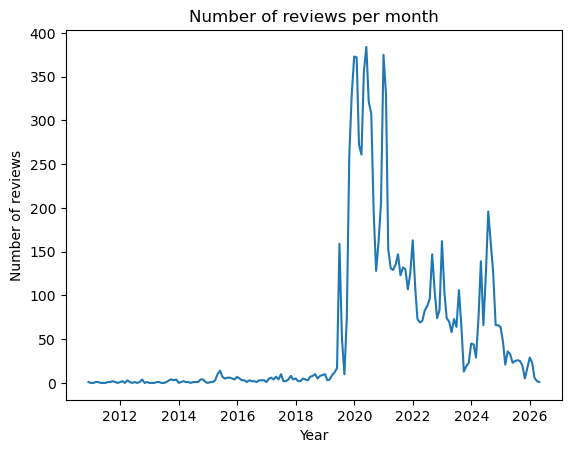

In [4]:
import matplotlib.pyplot as plt
df['Data']=pd.to_datetime(df['Data'])
df=df.set_index('Data')

plt.plot(df['Testo_Recensione'].resample('ME').count())
plt.xlabel('Year')
plt.ylabel('Number of reviews')
plt.title('Number of reviews per month')
plt.show()

L'analisi della serie storica evidenzia tre fasi distinte, fondamentali per comprendere le dinamiche di ingaggio degli utenti:
- **Fase di Latenza (2011 - 2019)**: In questo esteso intervallo temporale, il volume delle recensioni risulta marginale e costante, rasentando lo zero. Questo andamento suggerisce che, in tale periodo, il canale Trustpilot non era il mezzo principale utilizzato per le recensioni (nato nel 2007 ma affermatosi solo dopo il 2015).

- **Picco di Adozione ed Espansione (2020 - 2022)**: Si osserva una rottura strutturale della serie storica a cavallo tra la fine del 2019 e l'inizio del 2020, con un'impennata che porta il volume a sfiorare le 400 recensioni mensili. Questa crescita esponenziale è verosimilmente attribuibile all'esplosione globale dell'e-commerce durante il periodo pandemico.

- **Fase di Assestamento e Volatilità (2023 - 2026)**: Superato il biennio di massima espansione, i volumi mostrano un trend decrescente ma caratterizzato da un'elevata volatilità. Spiccano picchi isolati (ad esempio, a metà del 2024, prossimo alle 200 recensioni), che potrebbero coincidere con specifici eventi di natura commerciale (saldi stagionali, Black Friday) o con problematiche logistiche generalizzate che hanno spinto gli utenti a condividere la propria esperienza. Negli ultimi mesi analizzati, il volume tende a stabilizzarsi verso valori contenuti.

L'osservazione di questa distribuzione temporale impone alcune scelte metodologiche per le successive fasi di Natural Language Processing (NLP):
- **Campionamento e Bilanciamento**: Essendo la stragrande maggioranza del corpus testuale concentrata nel periodo post-2019, i modelli di Topic Modeling (come l'LDA) e i classificatori rifletteranno inevitabilmente il linguaggio, i prodotti e le dinamiche logistiche di questo specifico periodo.

- **Gestione del Rumore**: Si potrebbe valutare l'esclusione delle recensioni antecedenti al 2019 dal dataset di addestramento. I volumi esigui di quegli anni non forniscono una base statistica sufficiente e rischiano di introdurre rumore senza apportare valore predittivo al modello di classificazione.

Successivamente si è proceduto con l'analisi della distribuzione delle recensioni in funzione del punteggio assegnato dagli utenti, le Stelle:

Distribuzione delle stelle : Stelle
5    7284
1    1148
4     951
3     424
2     292
Name: count, dtype: int64


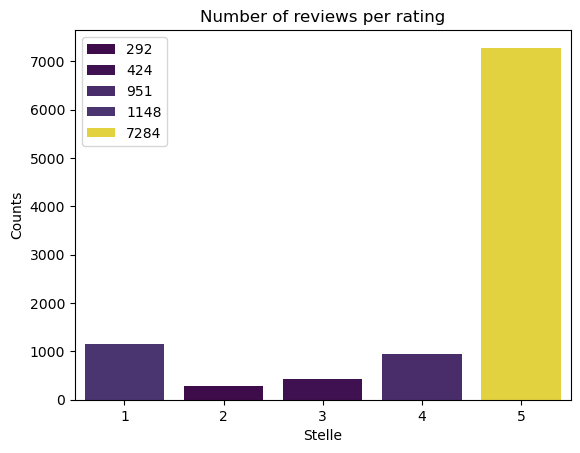

In [5]:
import seaborn as sns

star=df['Stelle'].value_counts()
print(f'Distribuzione delle stelle : {star}')
ax=sns.barplot(x=star.index, y=star.values, hue=star.values, palette='viridis', legend=True)
ax.set(ylabel='Counts')
plt.title('Number of reviews per rating')
plt.show()

Il grafico a barre illustra:
- La distribuzione presenta una marcata asimmetria (skewness), dominata in modo schiacciante dalla classe "5 stelle", che raggruppa la maggioranza assoluta delle osservazioni (7.284 recensioni).

- L'andamento osservato ricalca il tipico fenomeno della *curva a J*, ricorrente nella letteratura sulle recensioni online. Gli utenti mostrano una maggiore propensione a rilasciare feedback in corrispondenza di esperienze estreme: valutazioni eccellenti (5 stelle) o, in subordine, esperienze fortemente negative (1 stella, pari a 1.148 recensioni). Le esperienze neutre o mediocri (2 e 3 stelle) generano un coinvolgimento significativamente inferiore, risultando le classi meno rappresentate (rispettivamente 292 e 424 occorrenze).

- Da una prospettiva strettamente legata al business, la schiacciante prevalenza di recensioni a 4 e 5 stelle conferma un livello di Customer Satisfaction complessivamente molto elevato per il brand LuisaViaRoma, pur evidenziando una coorte non trascurabile di clienti profondamente insoddisfatti (1 stella) le cui motivazioni richiederanno un'indagine semantica approfondita (Topic Modeling).



Questa configurazione dei dati ha imposto un'attenta riflessione metodologica in vista dello sviluppo dei modelli predittivi. 

Dato che il dataset risulta severamente sbilanciato, l'addestramento diretto di un classificatore supervisionato (es. Logistic Regression applicata alla matrice Bag of Words) su questi dati "crudi" porterebbe il modello a sviluppare un forte bias verso la classe maggioritaria, cioè l'algoritmo tenderebbe a classificare quasi ogni testo come "5 stelle", ottenendo un'accuratezza (Accuracy) globalmente alta, ma parametri di Precision e Recall disastrosi per le classi minoritarie, in quanto considerate "rumore statistico".

Successivamente si è analizzata la lunghezza del testo delle recensioni.

Per farlo occorre prima creare nuove metriche a partire dalla colonna testo recensione, è prassi comune calcolare sia il numero di caratteri sia il numero di parole.

In [6]:
df['conteggio parole']=df['Testo_Recensione'].apply(lambda x: len(str(x).split()))
df['conteggio caratteri']=df['Testo_Recensione'].apply(lambda x: len(str(x)))

Spesso, nel text mining applicato al customer care, si osserva che le recensioni a 1 stella ( le lamentele) sono significativamente più lunghe e dettagliate rispetto a quelle a 5 stelle (elogi concisi come "Tutto perfetto").

Per visualizzare questa relazione, il grafico più indicato è il Boxplot, poiché mostra la mediana, la dispersione e soprattutto i valori anomali (outlier).

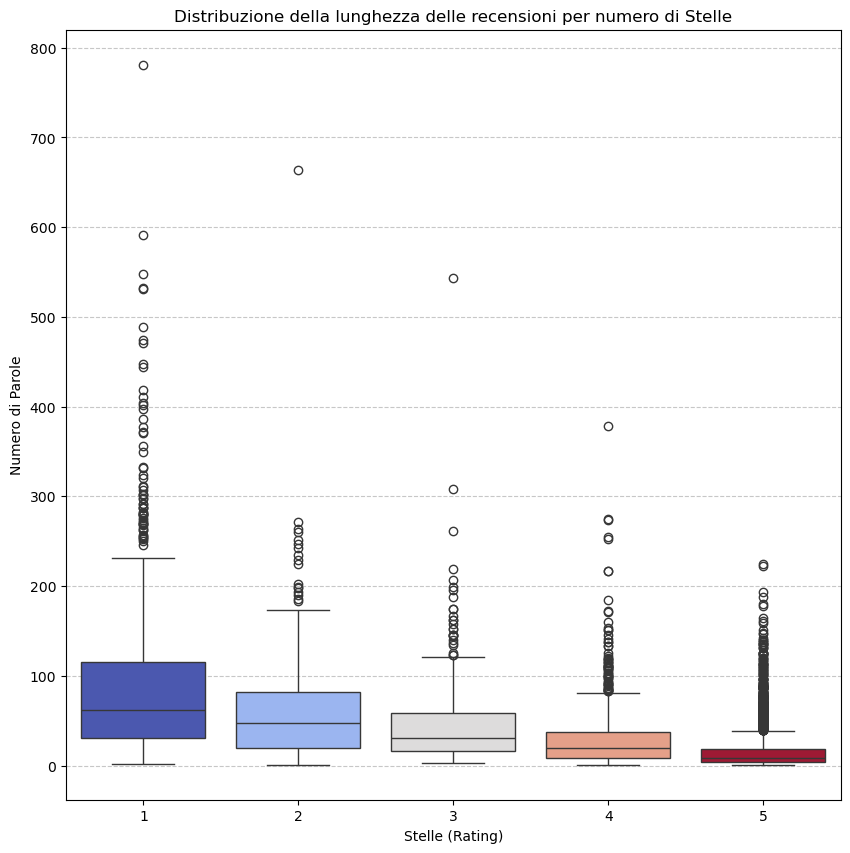

In [7]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='Stelle', y='conteggio parole', hue='Stelle', palette='coolwarm', legend=False)
plt.title('Distribuzione della lunghezza delle recensioni per numero di Stelle')
plt.xlabel('Stelle (Rating)')
plt.ylabel('Numero di Parole')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Si osserva una chiara relazione inversamente proporzionale tra il livello di soddisfazione dell'utente e la prolissità della recensione, le valutazioni a 1 stella presentano la mediana più elevata e il range interquartile (la dimensione della scatola, che racchiude il 50% centrale delle osservazioni) più esteso. Procedendo verso i punteggi più alti, la lunghezza mediana e la varianza dei dati si riducono progressivamente e in modo drastico.

La classe a 1 stella mostra una marcata coda superiore di outlier, con recensioni che sfiorano l'eccezionale lunghezza di 800 parole. 

Al contrario, la distribuzione per le 5 stelle risulta estremamente compressa: la stragrande maggioranza dei testi si concentra al di sotto delle 30 parole, e persino i valori estremi raramente superano la soglia delle 200 parole.

Questo andamento conferma empiricamente l'effetto di *venting* (sfogo) tipico delle piattaforme di recensione: un'esperienza fortemente negativa (ad esempio, problematiche legate ai resi, assistenza clienti carente o ritardi logistici) spinge l'utente a redigere resoconti lunghi, dettagliati e ricchi di contesto, viceversa, l'eccellenza del servizio (5 stelle) è vissuta come una conferma delle aspettative e viene tipicamente espressa mediante formule sintetiche ed elogi concisi ("Perfetto", "Spedizione velocissima", "Ottimo acquisto").



Questa forte disomogeneità strutturale nella lunghezza dei documenti comporta sfide tecniche specifiche per le successive fasi di pre-processing e modellazione:
- **Ponderazione delle Feature (TF-IDF vs. BoW)**: Poiché i documenti associati a sentiment negativo contengono un volume di testo nettamente superiore, l'utilizzo di una matrice Bag of Words basata sulle pure frequenze assolute (*Term Frequency*) rischierebbe di sbilanciare l'importanza dei termini presenti nei testi più lunghi. Si adotterà in seguito, per questo motivo, la vettorizzazione TF-IDF (*Term Frequency-Inverse Document Frequency*), che applica una penalizzazione basata sulla document frequency e normalizza i pesi, mitigando l'effetto distorcente della lunghezza.

- **Topic Modeling (LDA)**: I testi lunghi (1 e 2 stelle) forniranno un corpus caratterizzato da una maggiore ricchezza lessicale e da un contesto semantico più articolato, risulterà dunque più agevole ed efficace estrarre "topic" definiti e coerenti dalle lamentele. Al contrario, l'estrema brevità delle recensioni a 5 stelle potrebbe rendere l'estrazione degli argomenti latenti tramite LDA statisticamente più complessa, richiedendo un'ottimizzazione rigorosa dei parametri per evitare la generazione di cluster generici o privi di significato.


Sfruttando la colonna localizzazione, è possibile isolare l'impatto della localizzazione geografica sulla percezione del servizio offerto da LuisaViaRoma:

In [8]:
tot_locations=df['Localizzazione'].value_counts()
print(tot_locations)

Localizzazione
IT    4029
DE     654
GB     596
FR     522
US     519
      ... 
JO       1
AM       1
BZ       1
BR       1
IM       1
Name: count, Length: 107, dtype: int64


In totale ci sono 107 localizzazioni, ma il grafico risulterebbe sovraffollato, quindi si sono estratte solo le prime 20 top locations

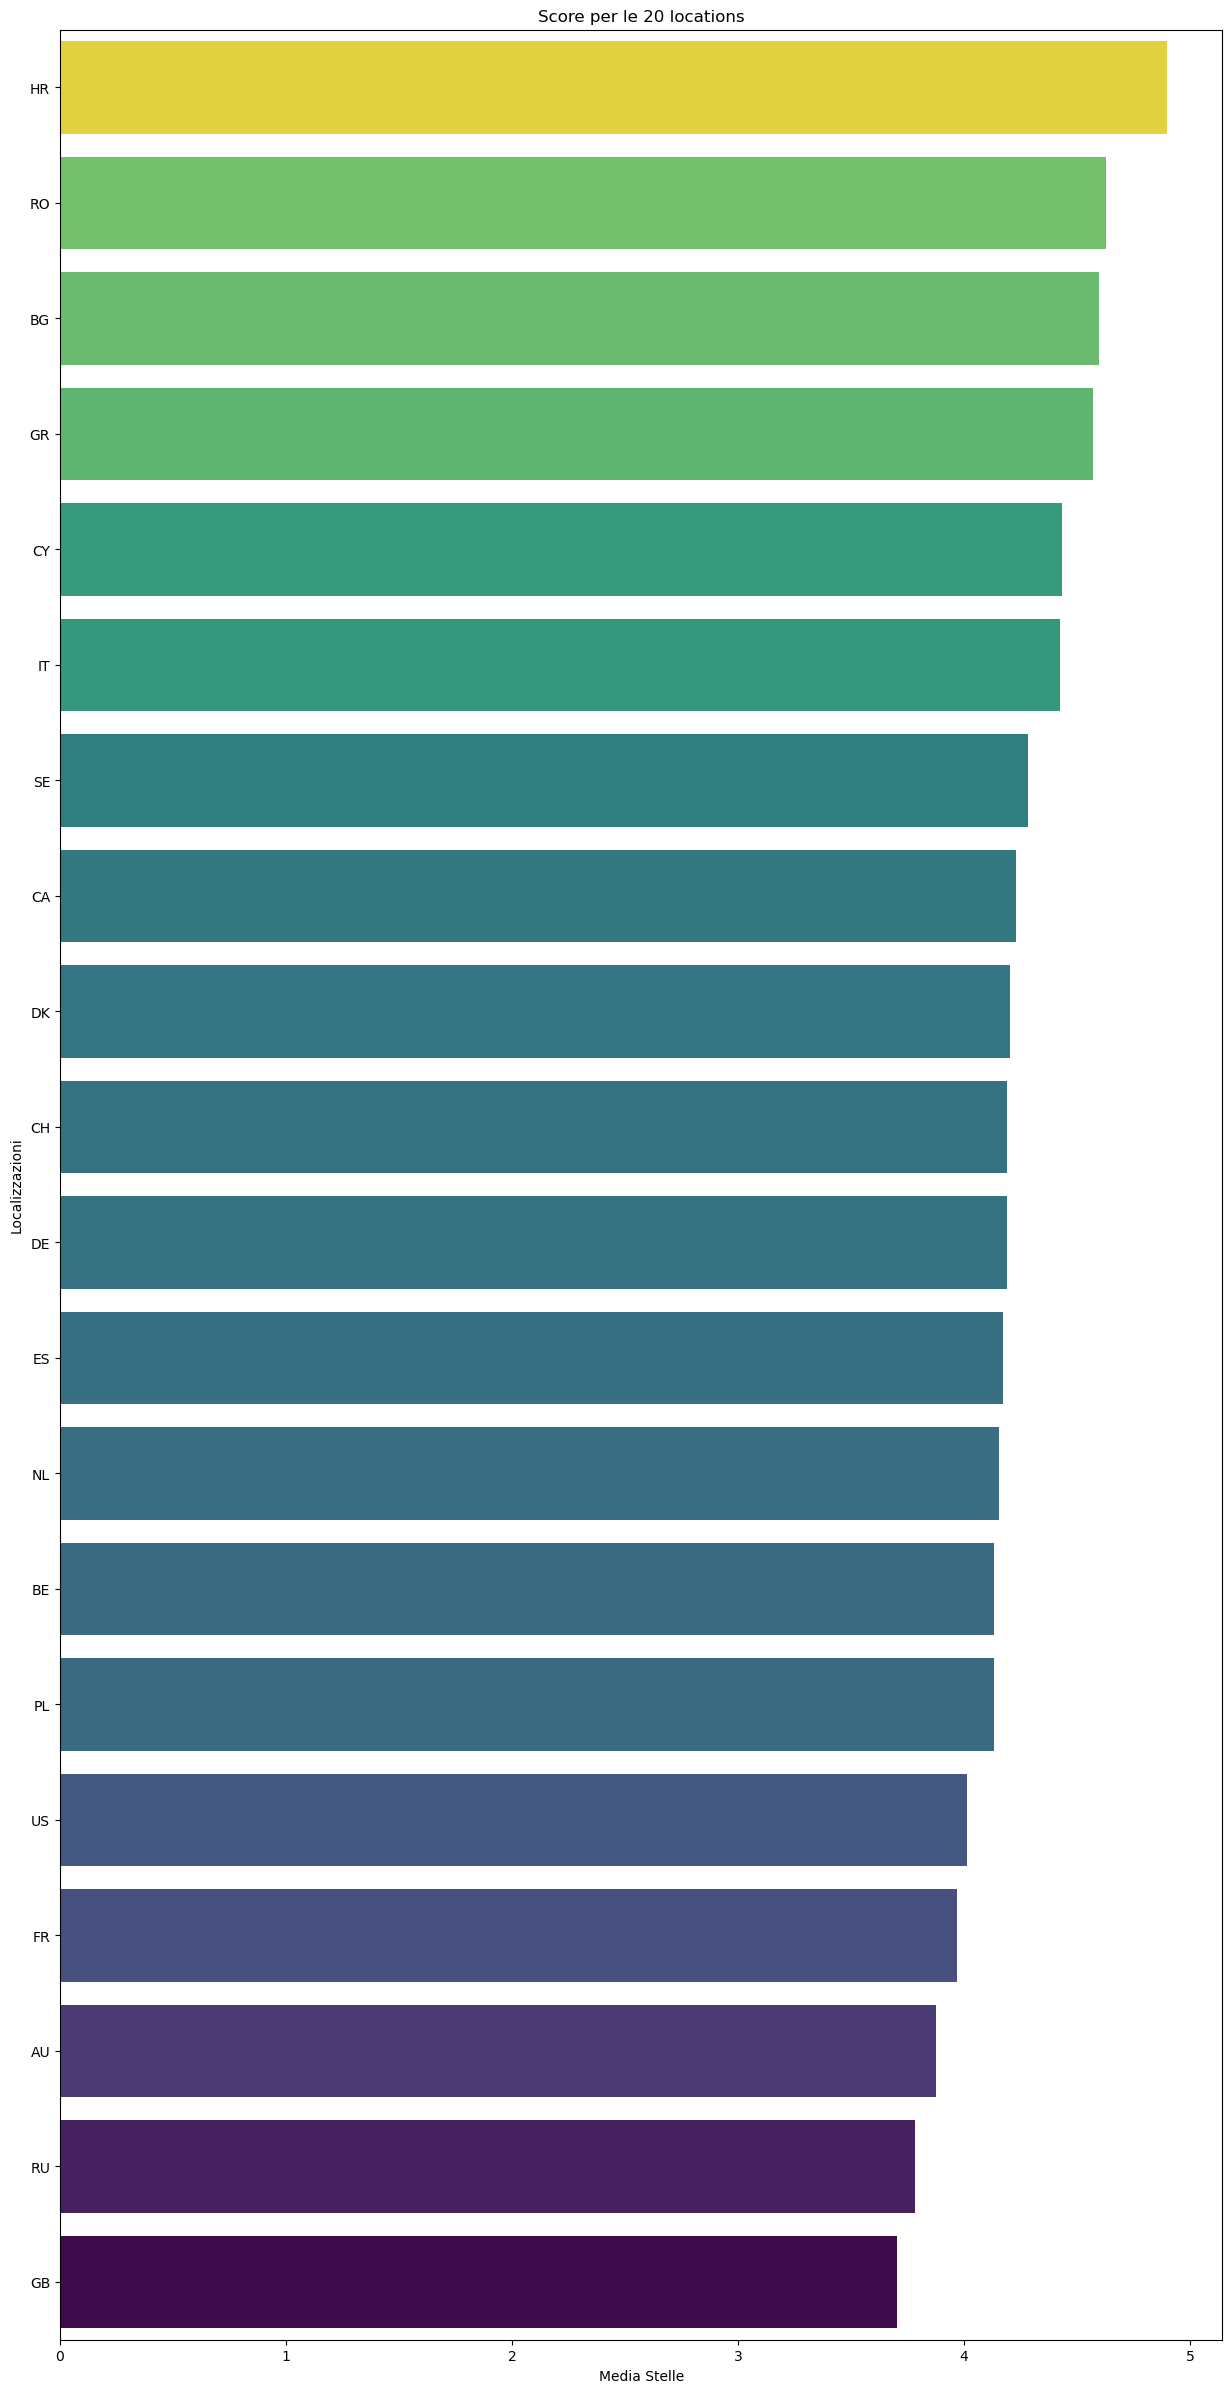

In [9]:
top_locations=tot_locations.head(20).index

df_top_loc=df[df['Localizzazione'].isin(top_locations)]
media_stelle_loc=df_top_loc.groupby('Localizzazione')['Stelle'].mean().sort_values(ascending=False)

plt.figure(figsize=(15,30))
sns.barplot(x=media_stelle_loc.values, y=media_stelle_loc.index, hue=media_stelle_loc.values, palette='viridis', legend=False)
plt.title('Score per le 20 locations')
plt.xlabel('Media Stelle')
plt.ylabel('Localizzazioni')
plt.show()

Il grafico a barre orizzontali illustra la soddisfazione media degli utenti, misurata in stelle, segmentata per le 20 aree geografiche (codici ISO dei Paesi) che registrano il maggior volume di recensioni.

La parte superiore del grafico è dominata da Nazioni come Croazia (HR), Romania (RO), Bulgaria (BG) e Grecia (GR), in particolare, il mercato croato registra un punteggio medio eccezionalmente elevato, prossimo al valore massimo di 5, questo può suggerire una logistica estremamente efficiente verso queste destinazioni o un posizionamento del brand che incontra perfettamente le aspettative di tale bacino d'utenza.

L'Italia (IT) si posiziona stabilmente nella fascia medio-alta della classifica, con una valutazione media ampiamente positiva (attorno al 4.4 - 4.5). Essendo il mercato domestico dell'azienda, questo dato consolida l'assunto di una generale soddisfazione della clientela italiana.

Il posizionamento del Regno Unito all'ultimo posto (con una media approssimativa di 3.7 stelle) rappresenta un segnale di allarme altamente specifico.


La netta spaccatura tra le performance dei Paesi europei (o limitrofi) e quelle dei Paesi extra-UE (o in contesti doganali complessi, come il Regno Unito post-Brexit) suggerisce che le determinanti della bassa soddisfazione in queste aree potrebbero non essere legate alla qualità del prodotto in sé, ma a fattori esogeni. Tra le cause più probabili (soprattutto dopo aver visionato in modo casuale qualche recensione del dataset) figurano:
- Tempi di spedizione dilatati per tratte intercontinentali.
- Gestione dei resi complessa o onerosa per l'utente estero.
- Sorprese relative all'applicazione di dazi doganali e tasse di importazione.

Per focalizzare l'attenzione sulle Nazioni che presentano le criticità maggiori, è necessario invertire la prospettiva dell'analisi precedente.

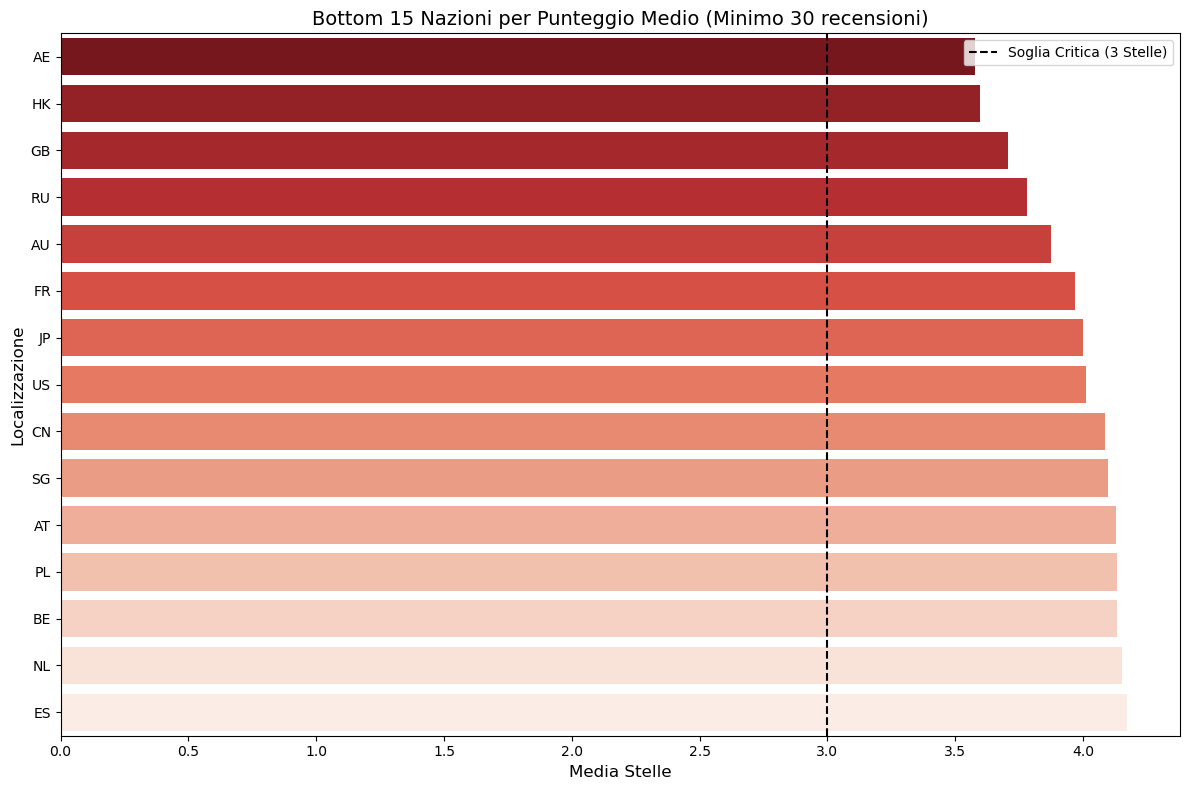

In [10]:


# 1. Impostare una soglia minima di recensioni per garantire la rilevanza statistica
soglia_minima = 30 

# 2. Calcolare il conteggio delle recensioni per ogni Nazione
conteggio_per_nazione = df['Localizzazione'].value_counts()

# 3. Filtrare solo le Nazioni che superano la soglia minima
nazioni_valide = conteggio_per_nazione[conteggio_per_nazione >= soglia_minima].index

# 4. Creare un subset del dataframe con le Nazioni filtrate
df_valido = df[df['Localizzazione'].isin(nazioni_valide)]

# 5. Calcolare la media delle stelle, ordinandole in modo crescente (dalla peggiore alla migliore)
peggiori_nazioni = df_valido.groupby('Localizzazione')['Stelle'].mean().sort_values(ascending=True)

# 6. Selezionare le 10 o 15 nazioni con il punteggio più basso
bottom_15_nazioni = peggiori_nazioni.head(15)

# Visualizzazione Grafica
plt.figure(figsize=(12, 8))
# Utilizziamo una palette di colori che enfatizzi le criticità (es. toni del rosso)
sns.barplot(x=bottom_15_nazioni.values, y=bottom_15_nazioni.index, palette='Reds_r', hue=bottom_15_nazioni.index, legend=False)

plt.title(f'Bottom 15 Nazioni per Punteggio Medio (Minimo {soglia_minima} recensioni)', fontsize=14)
plt.xlabel('Media Stelle', fontsize=12)
plt.ylabel('Localizzazione', fontsize=12)

# Aggiunta di una linea verticale per evidenziare la soglia di criticità (es. 3 stelle)
plt.axvline(x=3.0, color='black', linestyle='--', label='Soglia Critica (3 Stelle)')
plt.legend()
plt.tight_layout()
plt.show()

Il dato macroscopico più rilevante è che nessun mercato si posiziona al di sotto della soglia critica delle 3 stelle, persino l'area con la valutazione media più bassa (Emirati Arabi Uniti - AE) si attesta su un punteggio superiore a 3.5, ciò dimostra che LuisaViaRoma non riscontra fallimenti in alcun mercato consolidato.

Analizzando le posizioni di vertice del grafico (ovvero i punteggi peggiori in assoluto), emerge un pattern geografico inequivocabile. Le prime cinque nazioni appartengono tutte a contesti geografici extra-UE o caratterizzati da regimi di importazione specifici: Emirati Arabi Uniti (AE), Hong Kong (HK), Regno Unito (GB), Russia (RU) e Australia (AU).


Questa eterogeneità geografica porterà a degli accorgimenti nella fasi successive dell'analisi.

Dopo aver analizzato il volume delle recensioni nel tempo, si è analizzata la qualità nel tempo, fare ciò è utile per identificare eventuali 'crisi' (come ad esempio problemi legati ad un periodo particolare, come il periodo natalizio).

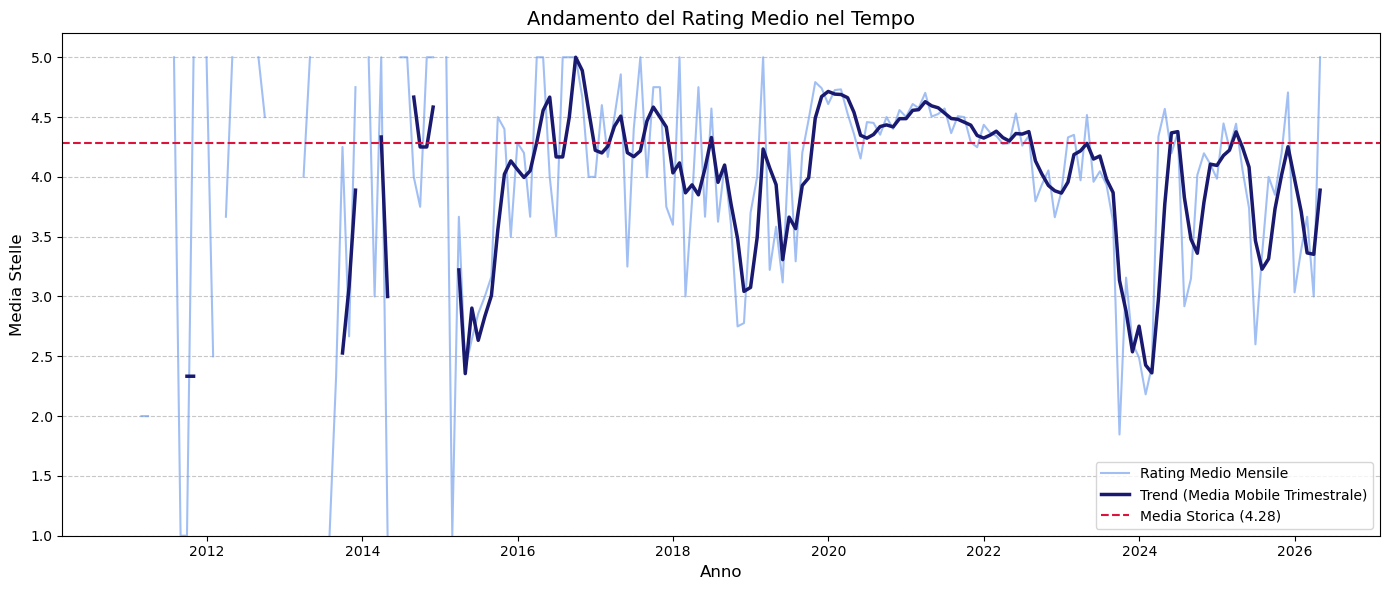

In [11]:
media_mensile = df['Stelle'].resample('ME').mean()

#media mobile trimestrale (3 mesi) per evidenziare il trend
media_mobile = media_mensile.rolling(window=3).mean()

# Creazione del grafico
plt.figure(figsize=(14, 6))

# Plot della media mensile (più chiara e sottile per mostrare la volatilità)
plt.plot(media_mensile.index, media_mensile.values, 
         label='Rating Medio Mensile', color='cornflowerblue', alpha=0.6, linewidth=1.5)

# Plot della media mobile (più marcata per evidenziare il trend)
plt.plot(media_mobile.index, media_mobile.values, 
         label='Trend (Media Mobile Trimestrale)', color='midnightblue', linewidth=2.5)

# Aggiunta di una linea di riferimento per la media storica globale
media_storica = df['Stelle'].mean()
plt.axhline(y=media_storica, color='crimson', linestyle='--', 
            label=f'Media Storica ({media_storica:.2f})')

plt.title('Andamento del Rating Medio nel Tempo', fontsize=14)
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Media Stelle', fontsize=12)
plt.ylim(1, 5.2) # Impostiamo i limiti dell'asse Y in base alla scala delle stelle
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Il grafico rivela tre macro-fasi distinte nella percezione qualitativa del brand:

- **Elevata Volatilità e Rumore Statistico (2012 - 2019)**: In questa prima fase, la curva presenta oscillazioni estreme e frammentate, con il punteggio mensile che rimbalza frequentemente tra i due estremi (1.0 e 5.0), questo comportamento non indica un'effettiva instabilità del servizio, ma è un artefatto statistico: i volumi di recensioni rasentavano lo zero, rendendo la media mensile estremamente sensibile al singolo feedback (outlier).

- **Fase di Stabilizzazione e "Golden Era" (2020 - metà 2023)**: In concomitanza con l'esplosione dei volumi (precedentemente documentata), si assiste a una drastica riduzione della volatilità. La media mobile trimestrale si stabilizza costantemente al di sopra della media storica, fluttuando in un corridoio di eccellenza tra 4.3 e 4.7. Questo fenomeno conferma che l'adozione su larga scala della piattaforma ha intercettato una clientela globalmente molto soddisfatta, "diluendo" fisiologicamente il peso delle recensioni negative di sfogo.

- **La "Rottura Strutturale" (Fine 2023 - 2024)**: Il dato più critico osserva a cavallo tra la fine del 2023 e l'inizio del 2024, il trend subisce un collasso verticale, con la media mobile che precipita rovinosamente fino a toccare il valore di 2.3 stelle, trascinata da medie mensili inferiori a 2.0. Anche nel biennio successivo (2024-2026), pur registrando dei parziali recuperi, il trend appare fortemente compromesso, viaggiando cronicamente al di sotto della soglia storica del 4.28, con flessioni marcate (es. metà 2025).

Dato che i dati antecedenti al 2019 presentano una numerosità troppo esigua e una volatilità estrema e mantenerli all'interno del corpus testuale rischierebbe di inserire un forte "rumore di fondo" statistico, penalizzando le performance dei futuri algoritmi di estrazione dei topic (LDA) e di classificazione.

Si procede quindi nel filtraggio del dataset:

In [12]:
# Stampiamo la dimensione del dataframe PRIMA del taglio
print(f"Dimensioni del Dataset Originale: {df.shape[0]} recensioni")

# Eseguiamo il filtraggio: manteniamo solo i record dal 1° Gennaio 2019 in poi
df = df.sort_index()
df_filtrato = df.loc['2019-01-01':]

# Stampiamo la dimensione del dataframe DOPO il taglio
print(f"Dimensioni del Dataset Filtrato (Post-2018): {df_filtrato.shape[0]} recensioni")
print(f"Recensioni eliminate: {df.shape[0] - df_filtrato.shape[0]}")

# Per comodità, riassegnamo df_filtrato a df per procedere con le fasi successive
df = df_filtrato.copy()

Dimensioni del Dataset Originale: 10099 recensioni
Dimensioni del Dataset Filtrato (Post-2018): 9810 recensioni
Recensioni eliminate: 289


Al fine di profilare in modo granulare i driver della Customer Satisfaction, il dataset è stato frammentato in funzione della variabile target (Sentiment *Positivo*, *Neutro* e *Negativo*).


Distribuzione delle classi:
Sentiment
Positivo    8038
Negativo    1365
Neutro       407
Name: count, dtype: int64


<Axes: ylabel='Sentiment'>

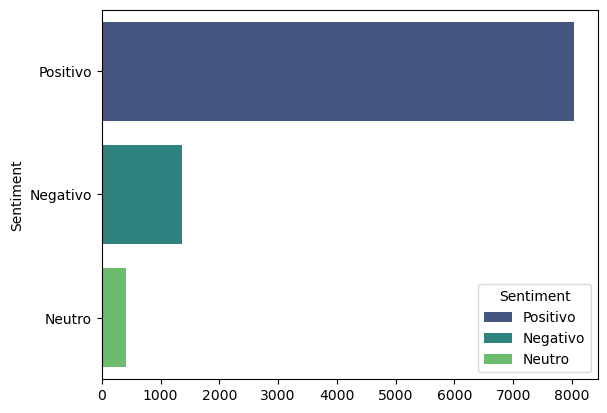

In [13]:
#mappatura del sentiment
def sentiment(stars):
    if stars>=4 :
        return 'Positivo'
    elif stars==3:
        return 'Neutro'
    else:
        return 'Negativo'

df['Sentiment']=df['Stelle'].apply(sentiment)
print('\nDistribuzione delle classi:')
distr=df['Sentiment'].value_counts()
print(distr)

import seaborn as sns
sns.barplot(x=distr.values, y=distr.index, hue=distr.index, palette='viridis', legend=True)

## Pre-Processing

L'obiettivo in questa fase è trasformare il testo grezzo e non strutturato in un formato normalizzato, matematicamente interpretabile e depurato da tutto il rumore semantico che non apporta valore informativo ai modelli predittivi.

Innanzitutto, dato che il dataset estratto dallo scraping è stato poi tradotto verifichiamo se vi sono stati dei fallimenti in questo processo di traduzione ed eliminiamo la "spazzatura":


In [14]:
from langdetect import detect, DetectorFactory
import langdetect

# Impostare un seed garantisce che l'algoritmo stocastico di langdetect restituisca risultati riproducibili a ogni esecuzione
DetectorFactory.seed = 0 

def verifica_lingua_inglese(testo):
    """
    Funzione per rilevare la lingua di una stringa di testo.
    Restituisce il codice ISO della lingua o 'unknown' in caso di errore.
    """
    try:
        # Verifica preventiva: il testo deve essere una stringa non nulla 
        # e sufficientemente lunga per permettere il rilevamento
        if not isinstance(testo, str) or len(testo.strip()) < 3:
            return 'unknown'
            
        return detect(testo)
        
    except langdetect.lang_detect_exception.LangDetectException:
        # Cattura le eccezioni generate da testi privi di caratteri alfabetici
        return 'unknown'

# 1. Creazione di una colonna temporanea con la lingua rilevata
colonna_testo = 'Testo_Recensione' 
df['Lingua_Rilevata'] = df[colonna_testo].apply(verifica_lingua_inglese)

# 2. Estrazione delle statistiche descrittive prima della pulizia
totale_iniziale = df.shape[0]
distribuzione_lingue = df['Lingua_Rilevata'].value_counts()

print("--- Statistiche di Language Detection ---")
print("Top 5 lingue rilevate nel corpus:")
print(distribuzione_lingue.head(5))
print("-" * 40)

# 3. Filtraggio: conservazione esclusiva dei documenti in lingua inglese
df_pulito = df[df['Lingua_Rilevata'] == 'en'].copy()

# 4. Report conclusivo
totale_finale = df_pulito.shape[0]
recensioni_eliminate = totale_iniziale - totale_finale

print(f"Dimensioni del Dataset Pre-Filtraggio : {totale_iniziale} recensioni")
print(f"Dimensioni del Dataset Post-Filtraggio: {totale_finale} recensioni")
print(f"Recensioni eliminate (traduzioni fallite o testo invalido): {recensioni_eliminate}")

# 5. Rimozione della colonna temporanea per mantenere pulito il dataframe
df = df_pulito.drop(columns=['Lingua_Rilevata'])

--- Statistiche di Language Detection ---
Top 5 lingue rilevate nel corpus:
Lingua_Rilevata
en    9003
ca     181
fr     168
ro      95
it      65
Name: count, dtype: int64
----------------------------------------
Dimensioni del Dataset Pre-Filtraggio : 9810 recensioni
Dimensioni del Dataset Post-Filtraggio: 9003 recensioni
Recensioni eliminate (traduzioni fallite o testo invalido): 807


Dopo il filtraggio si è proceduto con la classica pipeline di Pre-Processing dei testi:

1. **Lowercasing**: La conversione dell'intero corpus in caratteri minuscoli, questa operazione è fondamentale per evitare che l'algoritmo interpreti parole identiche scritte con capitalizzazione diversa (es. "Spedizione" e "spedizione") come due entità semantiche distinte.

2. **Data Cleansing tramite Espressioni Regolari (RegEx)**: Rimozione sistematica di URL, indirizzi e-mail, tag HTML, punteggiatura, simboli speciali, emoji ed eventuali cifre numeriche.

3. **Tokenizzazione**: La scomposizione di ogni singola recensione in unità atomiche denominate "token" (nella maggior parte dei casi coincidenti con le singole parole).

4. **Rimozione delle Stop-Words**: L'eliminazione delle parole vuote o connettivi logici (es. articoli, preposizioni, congiunzioni come "il", "di", "che", "e") che presentano un'elevatissima frequenza ma sono totalmente privi di potere discriminante per l'individuazione degli argomenti (LDA) o per la classificazione.

5. **Lemmatizzazione o Stemming**: Riconduce ogni token alla sua forma base o da dizionario (il "lemma") ed esegue un brutale taglio della parte finale della parola, rispettivamente.


Prima di applicare il pre-processing completo qui menzionato si è ispezionato preliminarmente l'intero corpus testuale senza eliminare le stopwords, per vedere quali di esse fossero importanti per l'analisi (perchè ad es: "non spedito" è diverso da "spedito"), qualora venissero eliminate tutte le stopwords senza essere analizzate si potrebbe perdere dell'informazione importante per l'analisi successiva.

In [15]:
#Pre-Processing
import seaborn as sns
from collections import Counter

def ispezione_iniziale(text):
    text=str(text).lower() #normalizzazione
    text=re.sub(r'[^a-z\s]', '', text) #rimozione punteggiatura, caratteri speciali e numeri
    tokens=text.split() #tokenizzazione
    return tokens

#estrazione di tutti i tokens
all_tokens1=[]
for text in df['Testo_Recensione']:
    all_tokens1.extend(ispezione_iniziale(text))

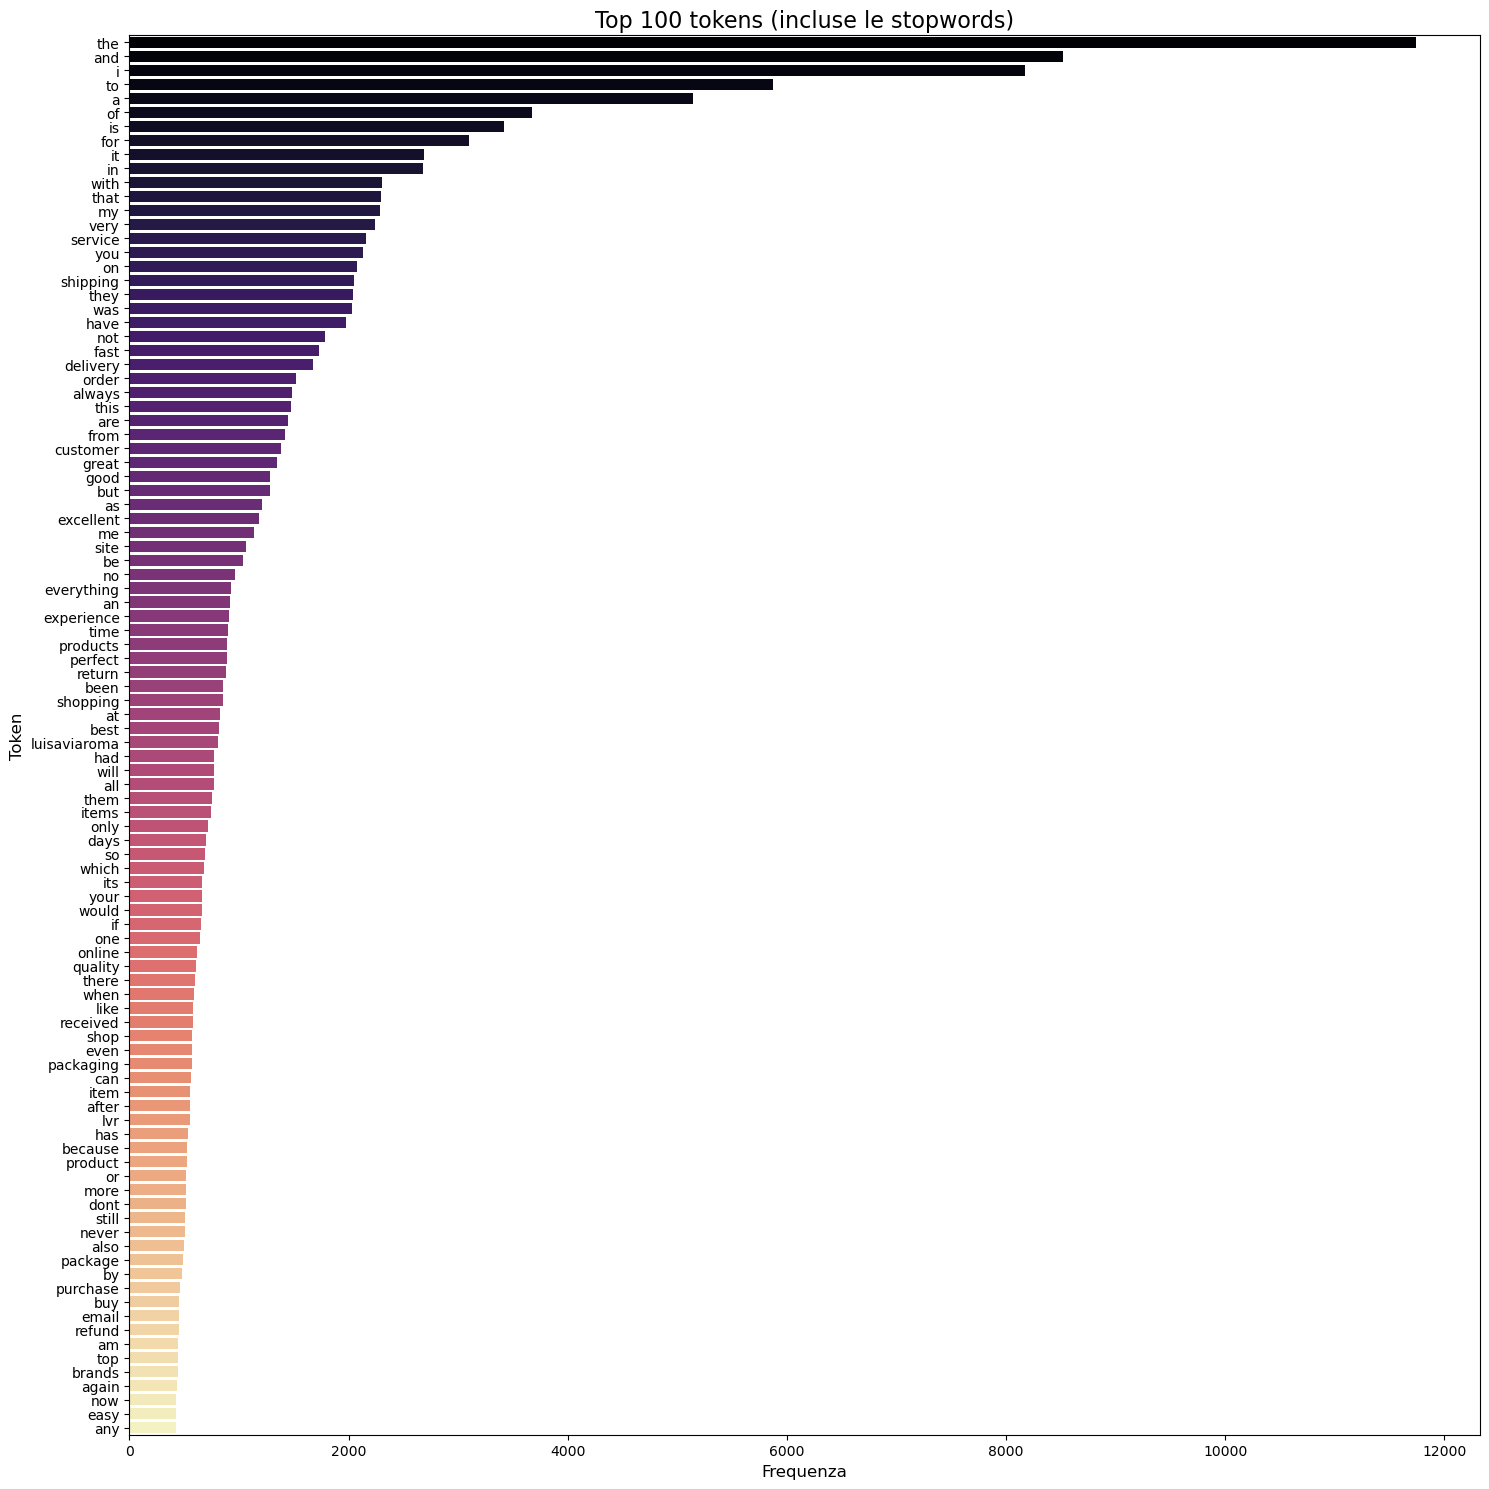

In [16]:
#calcolo le frequenze
token_counts1=Counter(all_tokens1)
top_tokens1=token_counts1.most_common(100)
df_tokens1=pd.DataFrame(top_tokens1, columns=['Token','Frequenza'])


#grafico
plt.figure(figsize=(15,15))
sns.barplot(x='Frequenza', y='Token', data=df_tokens1, palette='magma', hue='Token')
plt.title('Top 100 tokens (incluse le stopwords)', fontsize=16)
plt.xlabel('Frequenza', fontsize=12)
plt.ylabel('Token', fontsize=12)
plt.tight_layout()
plt.show()





Il grafico a barre orizzontali illustra i 100 termini più utilizzati all'interno del corpus di recensioni.

L'analisi di questa distribuzione rivela tre macro-dinamiche fondamentali per le successive fasi di Text Mining:

- Come atteso nella linguistica computazionale, le posizioni di vertice sono monopolizzate in modo schiacciante da articoli, congiunzioni e preposizioni ("the", "and", "i", "to", "a", "of"). Questi termini, pur costituendo l'ossatura grammaticale delle frasi, non veicolano alcun significato intrinseco associabile al brand o all'esperienza d'acquisto, confermando la necessità di una loro futura rimozione per i modelli basati su Bag of Words (BoW) e per il Topic Modeling (LDA).

- La scelta di adottare un pre-processing conservativo trova piena giustificazione empirica osservando il posizionamento di avverbi di negazione e congiunzioni avversative. Termini come "not", "but" e "no" figurano saldamente nella parte alta della classifica. La loro elevata frequenza dimostra che gli utenti ricorrono spesso a costrutti complessi o a inversioni di polarità (es. "good, but...", oppure "not fast"). L'eliminazione prematura di questi token avrebbe irrimediabilmente compromesso l'accuratezza delle successive fasi.

- Nonostante il "rumore di fondo" generato dalle stop-words, i sostantivi e gli aggettivi che riescono a scalare la classifica delineano già in modo netto gli argomenti centrali (topic) delle recensioni, in particolare emergono due filoni principali:
    1. **L'Area Logistica e di Servizio**: Parole come "service", "shipping", "delivery", "order", "return", "packaging" e "refund" evidenziano che l'esperienza post-acquisto e la gestione del pacco sono i driver principali delle recensioni.
    
    2. **Polarità Positiva**: Aggettivi come "great", "good", "excellent", "perfect" e "best" registrano frequenze altissime, allineandosi coerentemente con la massiccia asimmetria verso le 5 stelle osservata in precedenza nell'analisi dei metadati.

Al fine di validare empiricamente l'impatto delle stop-words e determinare quali costrutti lessicali guidino effettivamente la polarità delle recensioni, si è proceduto all'addestramento di un modello ad alberi decisionali (Random Forest Classifier), questa architettura è stata impiegata non con finalità puramente predittive, bensì come strumento di *Feature Selection* e ispezione semantica.

Il processo ha previsto i seguenti step analitici:

- **Vettorizzazione TF-IDF (Term Frequency-Inverse Document Frequency)**

- **Cattura del Contesto (N-grammi)**: Sono stati dati in pasto all'algoritmo non solo parole singole (unigrammi) ma anche coppie di parole adiacenti (bigrammi). Tale accorgimento è fondamentale per intercettare le inversioni di valenza semantica, catturando espressioni determinanti come "not received", "customer service", o "very bad", che verrebbero altrimenti scisse perdendo il loro significato originario.

- **Calcolo della Gini Importance**: L'algoritmo Random Forest quantifica l'importanza di ciascuna feature (in questo caso, il token o il bigramma) misurando la riduzione media dell'impurità di Gini attraverso tutti gli alberi della foresta. 


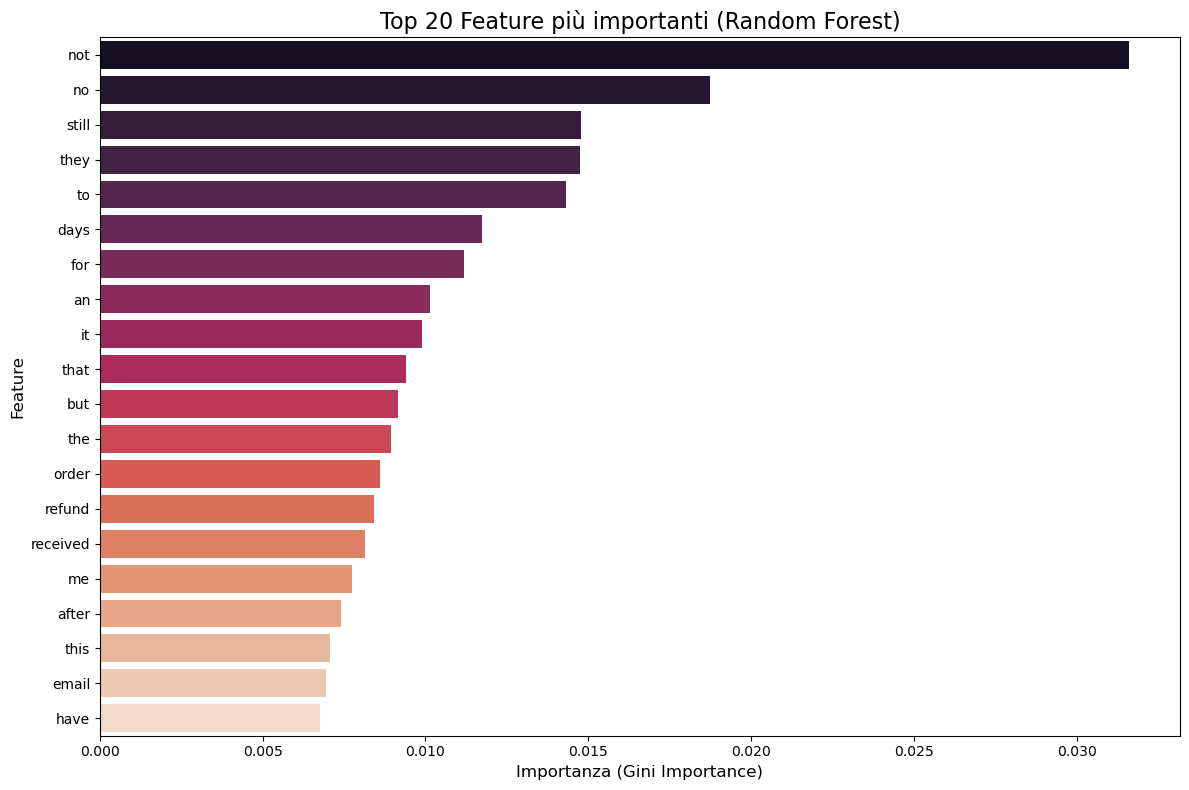

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

def pulizia_per_modello(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text # restituisce una stringa e non i tokens, essenziale per il TfidfVectorizer

df['Testo_Pulito'] = df['Testo_Recensione'].apply(pulizia_per_modello)

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['Testo_Pulito'])
y = df['Sentiment']

#modello
rf=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X,y)

#feature importance
importances = rf.feature_importances_
feature_names = vectorizer.get_feature_names_out()

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(20)

#grafico
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='rocket', hue='Feature')
plt.title('Top 20 Feature più importanti (Random Forest)', fontsize=16)
plt.xlabel('Importanza (Gini Importance)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

L'analisi dei 20 termini con il maggiore potere discriminante rivela le seguenti dinamiche fondamentali:

1. **La Supremazia Assoluta delle Negazioni**: I termini "not" e "no" dominano in modo incontrastato la classifica, distaccando nettamente tutte le altre feature. Rimuovere queste specifiche stop-words comporterebbe la perdita dei predittori più potenti dell'intero dataset.

2. **Bias di Lunghezza**: È interessante notare la forte presenza di pronomi personali e preposizioni apparentemente neutre ("they", "to", "for", "it", "me"). Questo fenomeno è il riflesso diretto di quanto scoperto nell'EDA sulla lunghezza dei testi (in particolare delle recensioni a 1 stella).

Questo test sancisce la necessità definitiva di utilizzare liste di filtraggio personalizzate, in particolare, per i modelli di classificazione del Sentiment, le negazioni e i modificatori devono essere conservati come elementi essenziali (al contrario, per estrarre i temi con la Latent Dirichlet Allocation (LDA), sarà vitale estendere la lista standard delle stop-words includendo termini come "they", "to", "for" e "me", affinché l'algoritmo non crei topic basati esclusivamente sulla grammatica narrativa).

Si è proceduto alla definizione di un dizionario di esclusione personalizzato, preservando tassativamente gli avverbi di negazione e i connettivi avversativi (es. not, no, never, but). Questa accortezza garantisce che i successivi modelli predittivi non perdano i modificatori di valenza che invertono la polarità del Sentiment.

La matrice risultante è stata vettorizzata tramite TF-IDF (Term Frequency-Inverse Document Frequency), includendo unigrammi e bigrammi per catturare il contesto ravvicinato. A scopo esplorativo, la somma dei pesi TF-IDF è stata visualizzata tramite una Word Cloud. A differenza delle visualizzazioni basate sulle frequenze assolute, questa rappresentazione grafica enfatizza i termini dotati di reale potere discriminante: le parole più grandi nella nuvola non sono semplicemente le più comuni, ma quelle che caratterizzano in modo più univoco gli specifici documenti in cui compaiono, riducendo ulteriormente il rumore di fondo.

Calcolo delle frequenze e dei pesi per la Word Cloud...

Top 15 Termini (Unigrammi e Bigrammi):
perfect: 317.89
very: 300.98
fast: 289.76
great: 275.69
service: 273.98
shipping: 259.54
excellent: 257.10
good: 234.54
delivery: 228.49
best: 218.76
shopping: 167.78
site: 167.45
experience: 159.04
products: 156.53
order: 149.18

Generazione Word Cloud in corso...


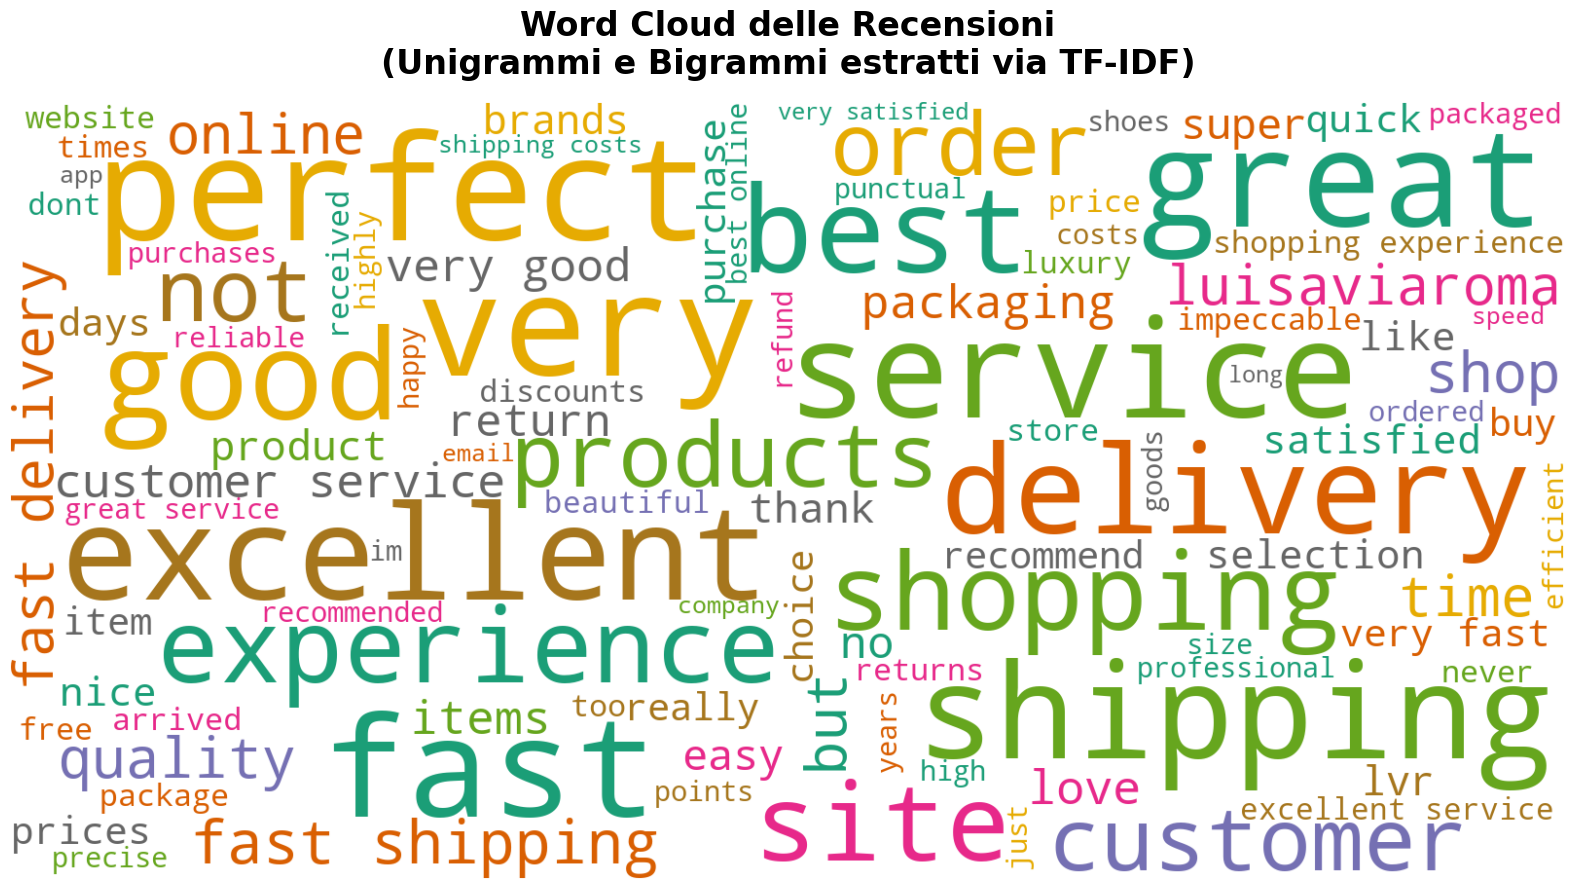

In [18]:
import numpy as np
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import warnings
from wordcloud import WordCloud
warnings.filterwarnings('ignore') # Omette i warning non critici

#lista stopwords personalizzata da non rimuovere
eccezioni = {
    'not', 'no', 'nor', 'but', 'never', 'nothing', 'none', 'cannot', 'cant', 
    'couldnt', 'doesnt', 'dont', 'hadnt', 'hasnt', 'havent', 'isnt', 'shouldnt', 
    'wasnt', 'werent', 'wont', 'wouldnt', 'too', 'very'
}

#sottraggo le eccezioni dalla lista standard di stopwords
custom_stopwords = set(ENGLISH_STOP_WORDS) - eccezioni

#pulizia
def pulizia_definitivo(text):
    text=str(text).lower()
    text=re.sub(r'[^a-z\s]','',text)
    tokens=text.split()
    clean_tokens=[word for word in tokens if word not in custom_stopwords]
    return ' '.join(clean_tokens)

#applico la pulizia
df['Testo_Pulito_Finale']=df['Testo_Recensione'].apply(pulizia_definitivo)

#tf idf e train/test split
vectorizer_final = TfidfVectorizer(max_features=4000, ngram_range=(1, 2))

X_final = vectorizer_final.fit_transform(df['Testo_Pulito_Finale'])
y_final = df['Sentiment']



print("Calcolo delle frequenze e dei pesi per la Word Cloud...")

# somma dei pesi TF-IDF per ogni termine lungo tutto il dataset
sum_words = X_final.sum(axis=0)

#creazione di una lista di tuple (parola, peso totale) mappando il vocabolario
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer_final.vocabulary_.items()]

#ordinamento dal termine più "pesante" a quello meno rilevante
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

#conversione in dizionario (formato richiesto dalla libreria WordCloud)
freq_dict = dict(words_freq)

#stampa di controllo dei primi 15 termini (singoli e bigrammi)
print("\nTop 15 Termini (Unigrammi e Bigrammi):")
for word, freq in words_freq[:15]:
    print(f"{word}: {freq:.2f}")

print("\nGenerazione Word Cloud in corso...")

#configurazione grafica della nuvola
wc = WordCloud(
    width=1600, 
    height=800, 
    background_color='white',
    colormap='Dark2',       
    max_words=100,          #limite per evitare sovrapposizioni illeggibili
    min_font_size=14,
    max_font_size=150,
    random_state=42         
)

#generazione passandogli il dizionario esatto che abbiamo costruito
wc.generate_from_frequencies(freq_dict)


plt.figure(figsize=(18, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud delle Recensioni\n(Unigrammi e Bigrammi estratti via TF-IDF)', fontsize=24, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()




L'ispezione della Word Cloud restituisce una sintesi visiva immediata dei fattori trainanti l'esperienza d'acquisto su LuisaViaRoma. Possiamo dunque osservare:
- Coerentemente con la marcata asimmetria della distribuzione delle recensioni (forte prevalenza di 5 stelle), lo spazio visivo è dominato da aggettivi a polarità marcatamente positiva. Termini come "perfect", "great", "best", "excellent" e "good" possiedono i pesi TF-IDF più elevati dell'intero corpus.

- L'algoritmo ha isolato concetti complessi che avrebbero perso significato se scissi (bigrammi): espressioni come "customer service", "fast delivery", "fast shipping" e "shopping experience" emergono chiaramente, fornendo un contesto che il singolo unigramma non avrebbe garantito.

- Sostantivi come "delivery", "service", "shipping", "order" e "packaging" costituiscono l'ossatura semantica delle recensioni, suggerendo che le performance logistiche sono il vero banco di prova per il giudizio degli utenti.

- È altresì visibile la presenza di termini come "not" e "but" (seppur con un peso inferiore rispetto agli aggettivi positivi). La loro emersione certifica il successo della lista di stop-words personalizzata: l'algoritmo ha mantenuto intatti questi snodi logici fondamentali, preparando una matrice ottimale per le successive fasi di classificazione.

A valle della rimozione delle stop-words canoniche, si è proceduto a un ulteriore raffinamento del vocabolario mirato all'eliminazione del rumore semantico di dominio. Nello specifico, sono state espunte tutte le occorrenze, gli acronimi e le varianti ortografiche riconducibili al nome del brand ("LuisaViaRoma", "LVR", ecc.- **Domain-Specific StopWords**). Tale operazione si rende metodologicamente necessaria poiché l'onnipresenza del target brand all'interno del corpus comporterebbe una distorsione algoritmica, specialmente in vista del Topic Modeling (LDA), impedendo l'emersione di cluster tematici informativi e indipendenti.

In [19]:
# 1. Definizione delle varianti del brand (tutto in minuscolo)
# È fondamentale includere acronimi e possibili spaziature errate
brand_stopwords = {
    'luisaviaroma', 'lvr', 'luisa', 'viaroma', 'luisavia', 
    'roma', 'luisa via roma', 'luisaviaromas'
}

# 2. Aggiornamento della lista delle stop-words personalizzate
# Uniamo il set precedente con il nuovo set del brand
custom_stopwords.update(brand_stopwords)

# 3. Aggiornamento della funzione di pulizia (se necessario ricompilarla)
def pulizia_senza_brand(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    
    # Manteniamo la parola se NON è nella nostra lista aggiornata
    clean_tokens = [word for word in tokens if word not in custom_stopwords]
    return ' '.join(clean_tokens)

# 4. Applicazione al dataframe
# Sovrascriviamo o creiamo una nuova colonna pronta per l'LDA e la classificazione
df['Testo_Pulito_Finale'] = df['Testo_Recensione'].apply(pulizia_senza_brand)

print("Pulizia completata: riferimenti al brand eliminati con successo.")

Pulizia completata: riferimenti al brand eliminati con successo.


Al fine di massimizzare la densità informativa della matrice documenti-termini, l'architettura di pre-processing è stata integrata con uno step di Lemmatization affiancato da una mappatura euristica dei sinonimi. A differenza del più aggressivo Stemming, che rischia di generare radici lessicali non intellegibili, si è optato per l'impiego del WordNetLemmatizer per ricondurre le variazioni morfologiche alla loro forma canonica da dizionario.

Parallelamente, si è proceduto alla costruzione di un dizionario di normalizzazione domain-specific. Termini semanticamente sovrapponibili o impiegati come sinonimi nel contesto e-commerce (quali shipping, shipment e dispatch) sono stati forzatamente fatti convergere verso un unico macro-concetto (delivery). Questa riduzione controllata della dimensionalità semantica consolida i pesi vettoriali e scongiura il rischio che l'algoritmo Latent Dirichlet Allocation (LDA) disperda l'attenzione su vocaboli concettualmente identici.

In [20]:
# Inizializzazione del lemmatizzatore
lemmatizer = WordNetLemmatizer()

# Costruzione del Dizionario dei Sinonimi (Domain-Specific)
# Le chiavi sono i termini da sostituire, i valori sono i "macro-token" di destinazione
dizionario_sinonimi = {
    'shipping': 'delivery',
    'shipment': 'delivery',
    'dispatch': 'delivery',
    'postage': 'delivery',
    'package': 'parcel',
    'box': 'parcel',
    'item': 'product',
    'goods': 'product',
    'garment': 'product',
    'client': 'customer',
    'purchaser': 'customer',
    'website': 'site',
    'webpage': 'site',
    'assistance': 'service',
    'support': 'service'
}

def lemmatizza_e_unifica(text):
    # La stringa è già stata precedentemente lowercased e pulita dalla punteggiatura
    tokens = text.split()
    tokens_processati = []
    
    for word in tokens:
        # 1. Lemmatizzazione (riconduce i plurali ai singolari)
        # Impostiamo pos='n' (noun) poiché la maggior parte dei nostri target sono sostantivi
        lemma = lemmatizer.lemmatize(word, pos='n')
        
        # 2. Mappatura dei Sinonimi
        # Se il lemma è presente nel nostro dizionario, lo sostituiamo con il macro-token
        if lemma in dizionario_sinonimi:
            lemma = dizionario_sinonimi[lemma]
            
        tokens_processati.append(lemma)
        
    return ' '.join(tokens_processati)

# Applicazione della funzione alla colonna già pulita dalle stop-words e dal brand
df['Testo_Lemmatizzato'] = df['Testo_Pulito_Finale'].apply(lemmatizza_e_unifica)

#modifico la variabile X per includere i testi lemmatizzati e unificati
X_final = vectorizer_final.fit_transform(df['Testo_Lemmatizzato'])

print("Lemmatizzazione e mappatura dei sinonimi completata con successo.")

Lemmatizzazione e mappatura dei sinonimi completata con successo.


Ai fini puramente esplorative si sono visualizzate le Word Cloud per ogni sentiment (Positivo, Negativo e Neutro):

Generazione delle Word Cloud separate per Sentiment...
--- TOP 15 TERMINI: RECENSIONI POSITIVE ---
delivery: 382.8858
perfect: 335.6035
fast: 317.7742
great: 294.4694
service: 289.8017
excellent: 276.2208
product: 275.3839
good: 268.8278
best: 239.5925
fast delivery: 232.1715
site: 216.6857
shopping: 183.5968
experience: 170.5949
time: 141.0434
customer: 132.0859
----------------------------------------
--- TOP 15 TERMINI: RECENSIONI NEUTRE ---
delivery: 25.4775
product: 17.7523
order: 17.7314
time: 13.0455
site: 12.7434
return: 11.9250
day: 11.2281
customer: 11.1118
service: 10.9189
cost: 10.6320
good: 10.6201
delivery cost: 10.1495
long: 8.8751
parcel: 8.5359
free: 8.1894
----------------------------------------
--- TOP 15 TERMINI: RECENSIONI NEGATIVE ---
order: 73.7982
delivery: 71.8129
product: 59.4086
service: 58.9855
customer: 58.1191
day: 50.4545
return: 46.1961
parcel: 44.6073
customer service: 44.1887
time: 41.8473
email: 40.1357
received: 38.0239
refund: 36.0033
site: 35.0389

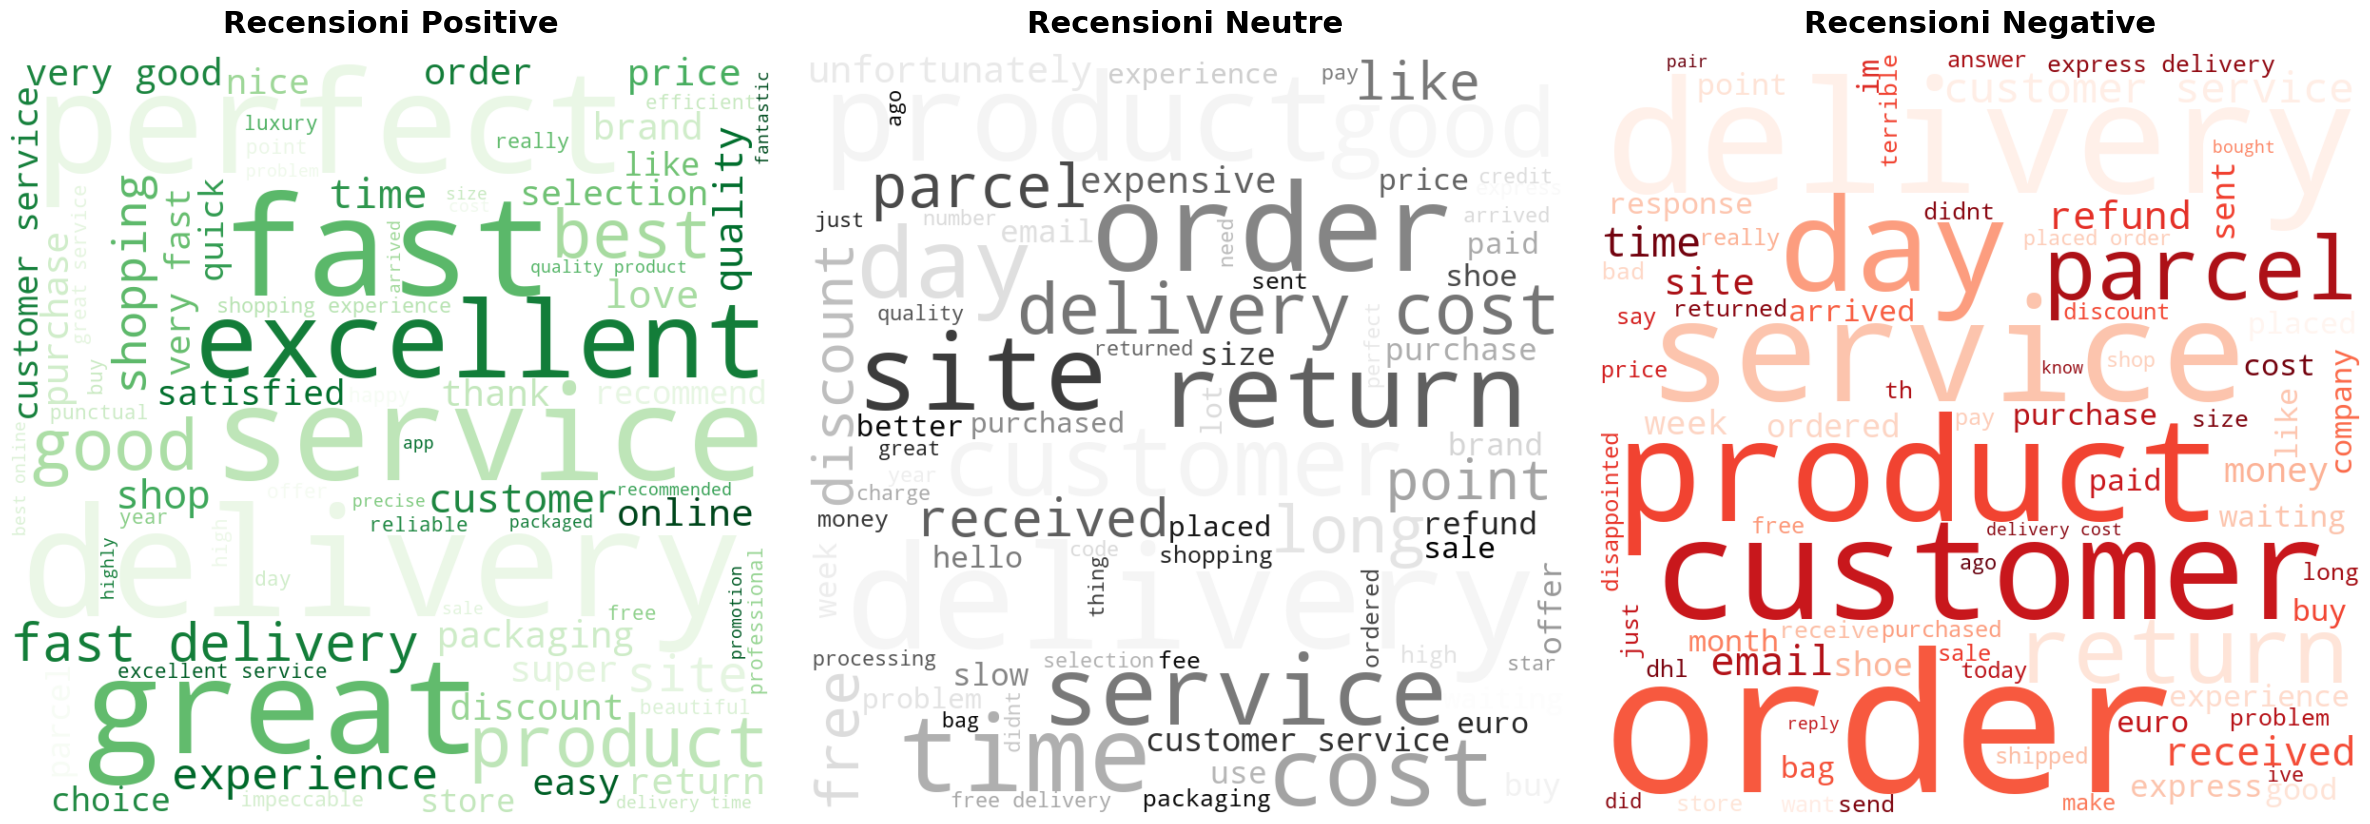

In [21]:
print("Generazione delle Word Cloud separate per Sentiment...")

def crea_wordcloud_per_classe(dati_testo, titolo, colormap, asse):
    #(estraiamo unigrammi e bigrammi)
    # max_features=1000 è sufficiente per le top words
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
    X_vec = vec.fit_transform(dati_testo)
    
    
    sum_words = X_vec.sum(axis=0)
    freq_dict = {word: sum_words[0, idx] for word, idx in vec.vocabulary_.items()}
    
    for ecc in eccezioni:  #filtro per rimuovere le negazioni singole come 'no' 'not' e conservare solo i bigrammi
        if ecc in freq_dict:
            del freq_dict[ecc]
            
    #ordiniamo il dizionario dal termine più frequente al meno frequente
    words_freq_sorted = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)
    
    
    print(f"--- TOP 15 TERMINI: {titolo.upper()} ---")
    for word, freq in words_freq_sorted[:15]:
        print(f"{word}: {freq:.4f}")
    print("-" * 40)


    
    wc = WordCloud(
        width=800, 
        height=800, 
        background_color='white',
        colormap=colormap,       
        max_words=75,            # Numero massimo di parole per pannello
        min_font_size=12,
        random_state=42
    )
    
   
    wc.generate_from_frequencies(freq_dict)
    
    #disegno sull'asse specificato
    asse.imshow(wc, interpolation='bilinear')
    asse.set_title(titolo, fontsize=22, fontweight='bold', pad=15)
    asse.axis('off')


#(1 riga, 3 colonne)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

#filtriamo i testi in base al Sentiment
testi_positivi = df[df['Sentiment'] == 'Positivo']['Testo_Lemmatizzato']
testi_neutri   = df[df['Sentiment'] == 'Neutro']['Testo_Lemmatizzato']
testi_negativi = df[df['Sentiment'] == 'Negativo']['Testo_Lemmatizzato']

#disegniamo le tre nuvole passando i dati, il titolo, il colore e l'asse di destinazione
crea_wordcloud_per_classe(testi_positivi, 'Recensioni Positive', 'Greens', axes[0])
crea_wordcloud_per_classe(testi_neutri,   'Recensioni Neutre',   'Greys',  axes[1])
crea_wordcloud_per_classe(testi_negativi, 'Recensioni Negative', 'Reds',   axes[2])


plt.tight_layout()
plt.show()

Il pannello di sinistra (verde) è inequivocabilmente dominato da aggettivi qualificativi di grado assoluto (perfect, excellent, great, best) fortemente associati al concetto di velocità (fast, fast delivery, quick). Questo dimostra che, quando il flusso logistico si svolge senza intoppi, l'esperienza d'acquisto viene percepita come impeccabile, esaltando la combinazione tra prodotto di lusso ed efficienza del servizio.

Il pannello di destra (rosso) restituisce la diagnosi più severa per il business. L'area semantica non ruota attorno alla scarsa qualità dell'abbigliamento, ma evidenzia un fallimento sistemico nel post-vendita. I lemmi più pesanti (customer, service, order, parcel, delivery, time, day, refund, email) compongono una narrativa inequivocabile: l'insoddisfazione profonda nasce da ordini non consegnati nei tempi previsti (time, day), necessità di contattare ripetutamente l'assistenza (email, customer service) e criticità nella ricezione dei rimborsi (refund).

## Text Classification
L'obiettivo di questa fase analitica è la transizione da un approccio esplorativo a uno predittivo. Sfruttando la rappresentazione vettoriale dei documenti (matrice TF-IDF), si intende addestrare algoritmi di Machine Learning capaci di apprendere i pattern linguistici e le associazioni semantiche che determinano la polarità di una recensione. Lo scopo ultimo è sviluppare un classificatore automatico in grado di assegnare istantaneamente il corretto Sentiment (Positivo, Neutro o Negativo) a futuri feedback testuali in ingresso, senza necessità di intervento umano.

Per garantire la massima robustezza metodologica e scongiurare il rischio di *overfitting* (sovradattamento), l'architettura di validazione è stata strutturata su due livelli:
- **Train/Test Split**: Il corpus è stato diviso preservando un 20% dei dati originari come Test Set isolato. La stratificazione ha garantito che le proporzioni delle tre classi di Sentiment rimanessero inalterate in entrambi i sottoinsiemi.
- **Stratified K-Fold Cross-Validation**: Sul restante 80% dei dati (*Train Set*), i modelli sono stati sottoposti a una validazione incrociata a 5 partizioni. Questa tecnica permette di misurare l'accuratezza media e la varianza delle performance, assicurando che il modello sia stabile e generalizzabile.

Sono state messe a confronto quattro diverse famiglie algoritmiche, dalle più tradizionali per l'analisi testuale alle più complesse:
- **Multinomial Naive Bayes**: Un modello probabilistico di baseline, molto efficace ed efficiente su matrici sparse come il Bag of Words o il TF-IDF.
- **Decision Tree**: Un modello basato su regole di partizione gerarchiche.
- **Random Forest**: Un metodo ensemble che aggrega molteplici alberi decisionali per ridurre la varianza e aumentare la robustezza predittiva.
- **Support Vector Machine (SVM con Kernel Lineare)**: Un algoritmo geometrico particolarmente indicato per spazi ad altissima dimensionalità (come il vocabolario testuale), capace di tracciare iper-piani di separazione ottimali tra le classi.

Oltre all'Accuratezza Globale (Accuracy), i modelli sono stati valutati mediante il Classification Report, prestando particolare attenzione a metriche quali Precision, Recall e F1-Score, indispensabili per valutare le reali performance su dataset sbilanciati.


In [22]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

models = {
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (Linear)': SVC(kernel='linear', random_state=42)
}

accuracies = {}
conf_matrices = {}
class_names = ['Negativo', 'Neutro', 'Positivo']

print('\n' + '='*60)
print('Inizio addestramento con Cross-Validation e Test Set')
print('='*60)

# K-Fold Stratified a 5 partizioni
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Cross-Validation su Train Set 
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()

    #addestramento finale sull'intero Train Set
    model.fit(X_train, y_train) 

    #predizione sui dati mai visti (Test Set)
    y_hat = model.predict(X_test) 

   
    acc = accuracy_score(y_test, y_hat)
    accuracies[name] = acc
    conf_matrices[name] = confusion_matrix(y_test, y_hat)

    # stampa a video dei risultati per ciascun modello
    print(f'Modello: {name}')
    print(f'Accuratezza CV (5-fold) su Train : {mean_acc:.4f} (+/- {std_acc:.4f})') 
    print(f'Accuratezza su Test Set          : {acc:.4f}') 
    print('-'*60)
    print(classification_report(y_test, y_hat, target_names=class_names))
    print('\n')


Inizio addestramento con Cross-Validation e Test Set
Modello: Naive Bayes
Accuratezza CV (5-fold) su Train : 0.9172 (+/- 0.0028)
Accuratezza su Test Set          : 0.9200
------------------------------------------------------------
              precision    recall  f1-score   support

    Negativo       0.79      0.87      0.82       269
      Neutro       0.00      0.00      0.00        80
    Positivo       0.95      0.98      0.96      1452

    accuracy                           0.92      1801
   macro avg       0.58      0.62      0.60      1801
weighted avg       0.88      0.92      0.90      1801



Modello: Decision Tree
Accuratezza CV (5-fold) su Train : 0.8543 (+/- 0.0066)
Accuratezza su Test Set          : 0.8545
------------------------------------------------------------
              precision    recall  f1-score   support

    Negativo       0.64      0.62      0.63       269
      Neutro       0.15      0.10      0.12        80
    Positivo       0.92      0.94      0

L'addestramento e la validazione dei quattro classificatori hanno restituito metriche di Accuratezza Globale (*Accuracy*) mediamente molto elevate, oscillanti tra l'85.43% del **Decision Tree** e il 91.64% della Support Vector Machine (**SVM**). Tutti i modelli hanno inoltre dimostrato un'eccellente robustezza, evidenziando uno scarto infinitesimale tra l'accuratezza in Cross-Validation (sui dati di addestramento) e quella calcolata sul Test Set. Questa assenza di overfitting valida l'efficacia del pre-processing (TF-IDF, Lemmatization, Stop-words).

**Il Paradosso dell'Accuracy e l'Illusione del Naive Bayes**: Il modello Multinomial Naive Bayes raggiunge un'ottima Accuracy (92.00%). Tuttavia, analizzando la classe "Neutro", si osserva un fallimento totale: Precision, Recall e F1-score sono pari a 0.00. L'algoritmo, guidato dalle frequenze probabilistiche, ignora completamente la classe minoritaria (80 osservazioni) per massimizzare la classificazione delle due classi principali. Questo dimostra come l'Accuracy globale non sia una metrica affidabile in contesti sbilanciati.

**La Difficoltà Semantica della Classe Neutra**: Tutti i modelli faticano enormemente nell'intercettare le recensioni Neutre. Anche il modello più performante (SVM) ottiene un Recall del solo 0.04 su questa classe (ovvero, individua solo il 4% dei veri Neutri), la "zona neutra" è un terreno di scontro semantico in cui le lamentele logistiche convivono con apprezzamenti sul prodotto, tale ambivalenza impedisce all'algoritmo vettoriale di tracciare confini netti.

**La Support Vector Machine con kernel lineare emerge oggettivamente come l'architettura superiore.** 

Non solo registra l'Accuratezza Globale più alta (92.17%), ma offre le migliori prestazioni complessive sulle due classi di effettivo interesse per il business: i Positivi (F1-score 0.97) e i Negativi (F1-score 0.83). 

La SVM si dimostra l'algoritmo geometricamente più idoneo a gestire l'elevata dimensionalità della matrice TF-IDF, tracciando iperpiani di separazione più netti rispetto agli algoritmi ad albero o probabilistici.


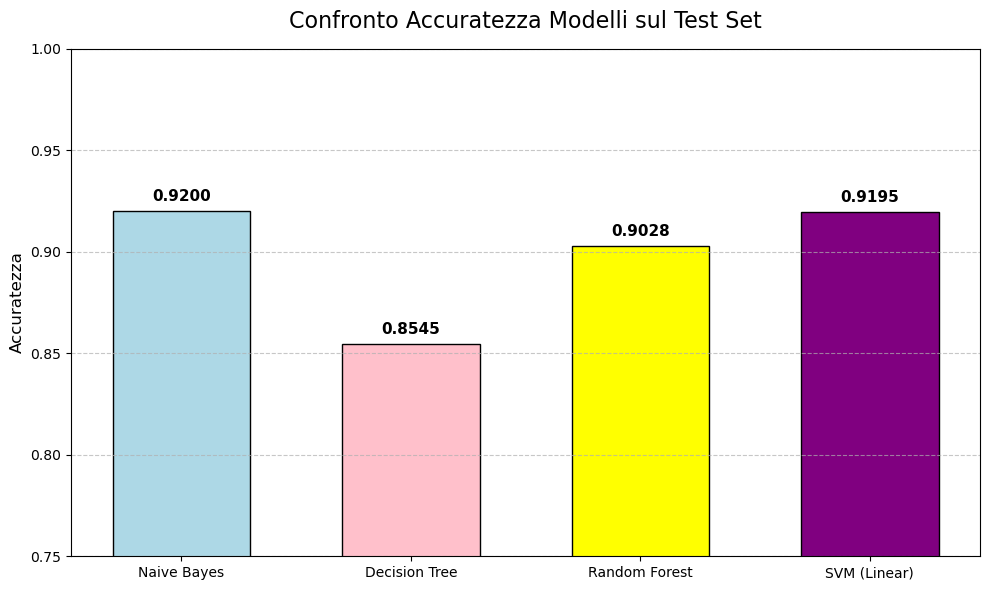

In [23]:
plt.figure(figsize=(10, 6))
colori = ['lightblue', 'pink', 'yellow', 'purple']


plt.bar(accuracies.keys(), accuracies.values(), color=colori, edgecolor='black', width=0.6)
plt.title('Confronto Accuratezza Modelli sul Test Set', fontsize=16, pad=15)
plt.ylabel('Accuratezza', fontsize=12)
plt.ylim(0.75, 1.0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

#aggiunta delle etichette dei valori sopra le barre
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

La rappresentazione grafica delle performance dei classificatori tramite **Matrici di Confusione** permette di mappare visivamente la distribuzione degli errori e confermare le distorsioni indotte dallo sbilanciamento del dataset:

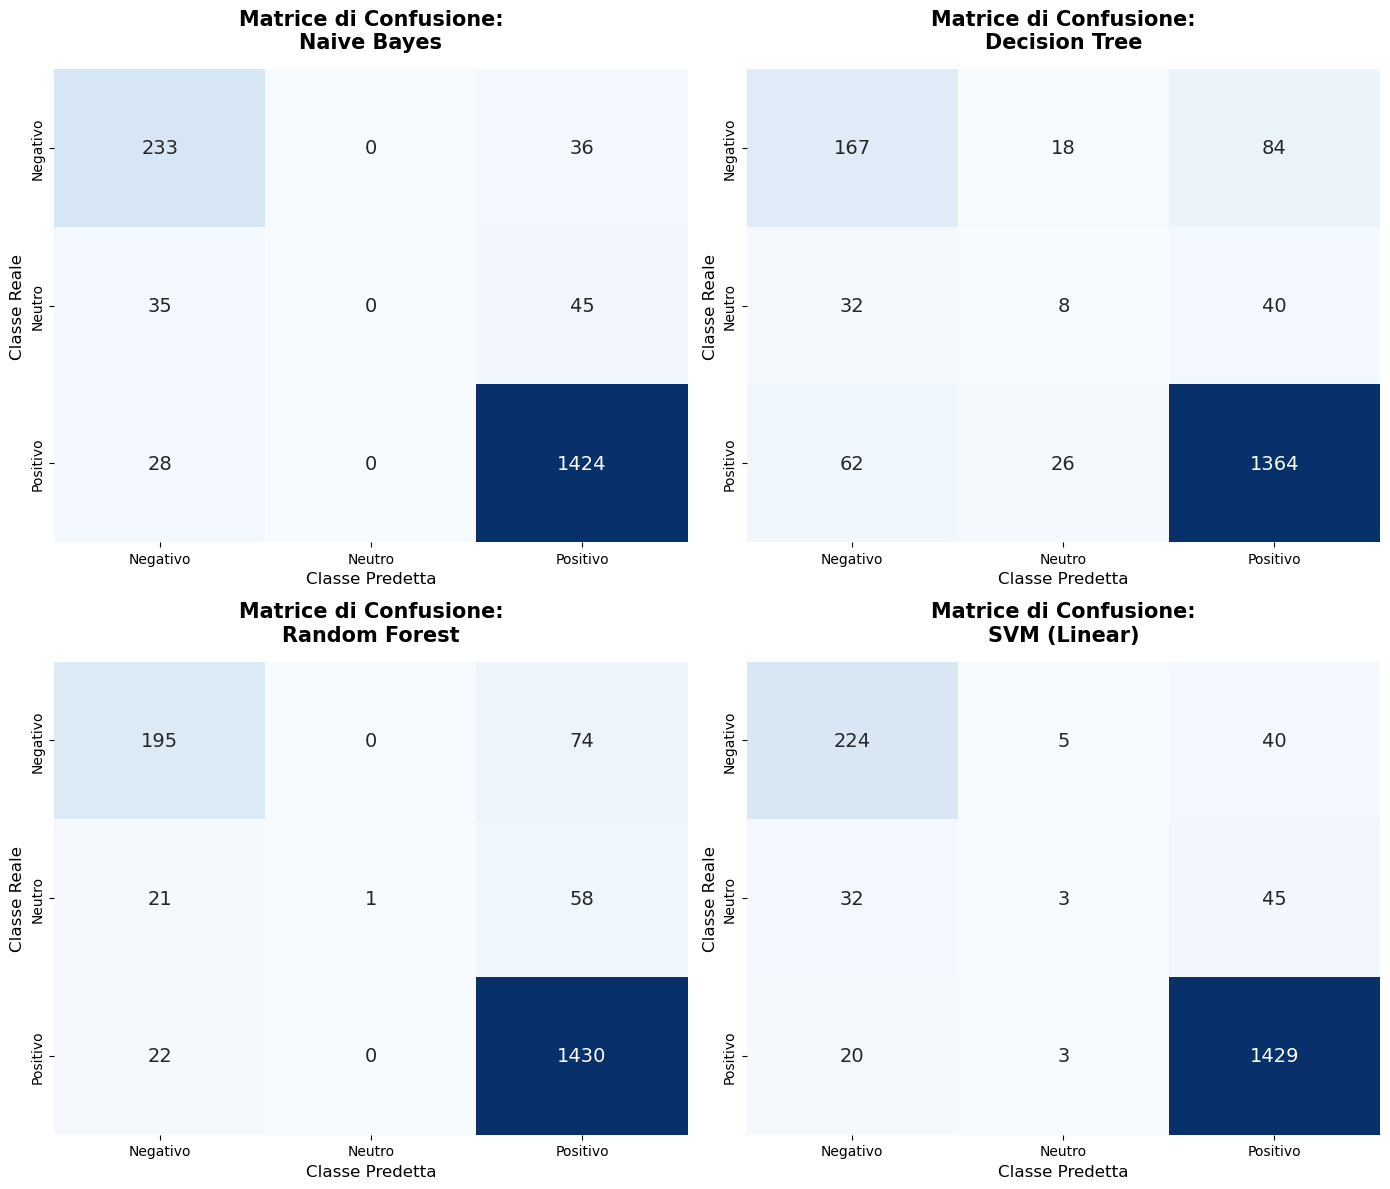

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

#per generare una matrice di confusione per ciascun modello
for idx, (name, matrix) in enumerate(conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, 
                annot_kws={"size": 14}, cbar=False)
    
    #personalizzazione dei titoli e degli assi
    axes[idx].set_title(f'Matrice di Confusione:\n{name}', fontsize=15, pad=15, fontweight='bold')
    axes[idx].set_xlabel('Classe Predetta', fontsize=12)
    axes[idx].set_ylabel('Classe Reale', fontsize=12)


plt.tight_layout()
plt.show()

L'anomalia statistica più evidente si osserva nella colonna centrale di quasi tutti i modelli (corrispondente alla classe predetta "Neutro"). Nel pannello del Naive Bayes, l'intera colonna registra il valore assoluto di zero: l'algoritmo non ha mai previsto la classe neutra, riversando gli errori sulle classi estreme. Anche Random Forest e SVM mostrano una colonna centrale quasi completamente sbiancata. Questo vuoto visivo certifica l'incapacità degli algoritmi vettoriali standard di isolare una firma semantica univoca per l'area di compromesso.

*Perché il Decision Tree performa "meglio" sui Neutri?*

La SVM cerca di tracciare un iperpiano (una linea di confine netta) nello spazio tridimensionale. Essendo la classe Neutra una "zona grigia" semantica (conterrà sia parole positive che negative), la SVM non riesce a isolarla e la divide tra Positivo e Negativo. L'Albero Decisionale, invece, procede per rigide spaccature binarie. Se trova una combinazione specifica (es. regola 1: contiene la parola "good", regola 2: contiene la parola "but"), crea un "ramo" dedicato, riuscendo a isolare fisicamente quel piccolo gruppo di testi.

Ci si aspetterebbe che il Random Forest faccia ancora meglio, in realtà, sui dataset fortemente sbilanciati avviene il contrario. Il Random Forest utilizza una tecnica chiamata bagging: ogni albero viene addestrato solo su un campione casuale dei dati ed essendo i Neutri pochissimi (solo 80), molti degli alberi non vedono un numero sufficiente di esempi Neutri per imparare a riconoscerli. Quando votano tutti insieme, la maggioranza (addestrata sui Positivi) "schiaccia" l'opinione dei pochi alberi che hanno visto i Neutri.

Un singolo Albero Decisionale ha la tendenza fisiologica a memorizzare a memoria il dataset di addestramento (overfitting). Questo gli permette di trovare pattern iper-specifici per i Neutri, ma ha un costo: la sua Precision è solo dello 0.15. Questo significa che, per trovare quel 9% di veri Neutri, etichetta erroneamente come Neutre un sacco di recensioni che non lo sono.

Pur riconoscendo che il Decision Tree sia il "migliore" tra i quattro sulla categoria *Neutri*, in ottica aziendale, un F1-Score di 0.12 significa che il modello è in estrema difficoltà. 

Se un'azienda avesse come obiettivo primario quello di intercettare specificamente i clienti "tiepidi" (i Neutri) per trasformarli in promotori del brand, nessuno di questi modelli, così come sono addestrati, potrebbe essere mandato in produzione.

Per risolvere questo problema alla radice e costringere gli algoritmi a rispettare la classe Neutra, si possono applicare tecniche di ribilanciamento avanzate prima di addestrare i modelli, come il sovra-campionamento (**SMOTE**).


In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('\n' + '='*60)
print('Inizio addestramento con SMOTE e Test Set')
print('='*60)

#inizializzazione di SMOTE
smote=SMOTE(random_state=42)

#applico smote solo sul train set
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#verifica del bilanciamento
print("Distribuzione delle classi PRIMA dello SMOTE:")
print(y_train.value_counts())
print("\nDistribuzione delle classi DOPO lo SMOTE:")
print(y_train_smote.value_counts())
print('-'*60)



Inizio addestramento con SMOTE e Test Set
Distribuzione delle classi PRIMA dello SMOTE:
Sentiment
Positivo    5805
Negativo    1075
Neutro       322
Name: count, dtype: int64

Distribuzione delle classi DOPO lo SMOTE:
Sentiment
Positivo    5805
Negativo    5805
Neutro      5805
Name: count, dtype: int64
------------------------------------------------------------


Poi si è proceduto all'addestramento dei modelli sul dataset bilanciato:


Inizio addestramento con Pipeline (SMOTE + Cross-Validation) e Test
Modello: Naive Bayes
Accuratezza CV (5-fold) con SMOTE integrato : 0.8611 (+/- 0.0033)
Accuratezza sul Test Set                   : 0.8617
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negativo       0.69      0.87      0.77       269
      Neutro       0.20      0.39      0.26        80
    Positivo       0.99      0.89      0.93      1452

    accuracy                           0.86      1801
   macro avg       0.62      0.71      0.65      1801
weighted avg       0.91      0.86      0.88      1801



Modello: Decision Tree
Accuratezza CV (5-fold) con SMOTE integrato : 0.8396 (+/- 0.0074)
Accuratezza sul Test Set                   : 0.8290
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negativo       0.60      0.60      0.60       269
      Neutro     

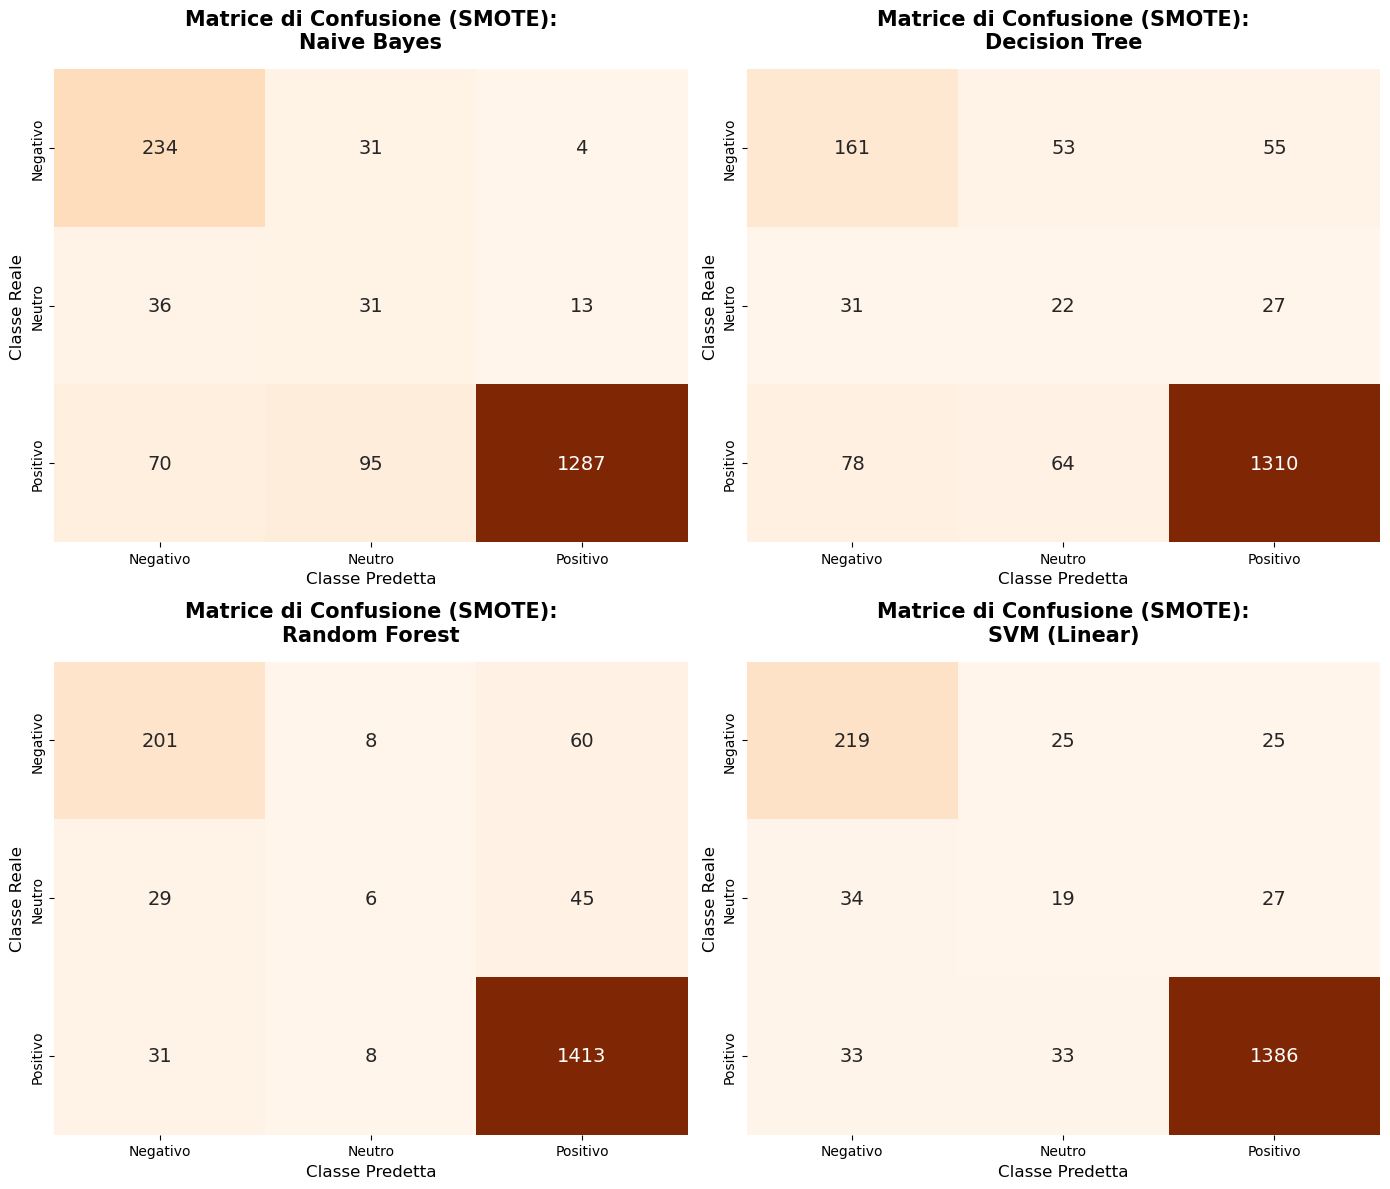

In [26]:
#addestro i modelli sui dati bilanciati
accuracies_smote = {}
conf_matrices_smote = {}

print('\n' + '='*70)
print('Inizio addestramento con Pipeline (SMOTE + Cross-Validation) e Test')
print('='*70)

for name, model in models.items():
    
    # creazione della Pipeline
    #la pipeline concatena sequenzialmente lo SMOTE e il classificatore.
    #durante la Cross-Validation, lo SMOTE genererà dati sintetici SOLO sui fold di addestramento.
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Cross-Validation Rigorosa
    # passiamo l'intera pipeline a cross_val_score, non il singolo modello
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()
    
    # addestramento Finale
    # Per addestrare il modello definitivo, applichiamo esplicitamente lo SMOTE sull'intero set di addestramento (X_train, y_train)
    smote_final = SMOTE(random_state=42)
    X_train_smote_final, y_train_smote_final = smote_final.fit_resample(X_train, y_train)
    
    model.fit(X_train_smote_final, y_train_smote_final)
    
    # Valutazione sul Test Set Incontaminato
    #effettuiamo le predizioni sui dati di test (X_test) che NON hanno mai subito sovracampionamento
    y_hat = model.predict(X_test)
    
    #calcolo e salvataggio delle metriche
    acc = accuracy_score(y_test, y_hat)
    accuracies_smote[name] = acc
    conf_matrices_smote[name] = confusion_matrix(y_test, y_hat)
    
   
    print(f'Modello: {name}')
    print(f'Accuratezza CV (5-fold) con SMOTE integrato : {mean_acc:.4f} (+/- {std_acc:.4f})')
    print(f'Accuratezza sul Test Set                   : {acc:.4f}')
    print('-'*70)
    print(classification_report(y_test, y_hat, target_names=class_names))
    print('\n')

# nuove Matrici di Confusione
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, matrix) in enumerate(conf_matrices_smote.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, 
                annot_kws={"size": 14}, cbar=False)
    
    axes[idx].set_title(f'Matrice di Confusione (SMOTE):\n{name}', fontsize=15, pad=15, fontweight='bold')
    axes[idx].set_xlabel('Classe Predetta', fontsize=12)
    axes[idx].set_ylabel('Classe Reale', fontsize=12)

plt.tight_layout()
plt.show()

**Il caso più eclatante di miglioramento si osserva nel modello Naive Bayes.**
Precedentemente "cieco" rispetto ai giudizi neutri (Recall 0.00), l'algoritmo, addestrato sul dataset bilanciato sinteticamente, riesce ora a intercettare il 39% dei Veri Neutri (Recall 0.39). La Matrice di Confusione riflette questo salto: la colonna centrale, prima vuota, si popola. Tuttavia, questo incremento di sensibilità si traduce in un crollo della Precision (0.16), generando un elevato numero di Falsi Neutri (95 recensioni positive classificate per errore come neutre).

Ancora una volta, la Support Vector Machine si dimostra l'architettura più equilibrata per questo dominio applicativo. Rispetto all'addestramento pre-SMOTE, la SVM incrementa il Recall sui Neutri (dal 4% al 24%) pur mantenendo saldi i parametri vitali sulle altre classi: un eccellente F1-score di 0.96 per le recensioni Positive e un robusto 0.79 per le Negative (identificando ben 219 lamentele reali su 269).

Il Random Forest, al contrario, è stato progettato per essere robusto e conservativo, interpreta le lievi sfumature dei dati sintetici generati dallo SMOTE come "rumore statistico" e, tramite il meccanismo del voto a maggioranza, le filtra e le annulla, ritornando al punto di partenza.

Si evince come lo SMOTE agisca sulla sintassi numerica del dataset, ma non possa colmare l'ambiguità semantica intrinseca della classe minoritaria.


Estrazione dell'Importanza delle Variabili (Coefficienti SVM)


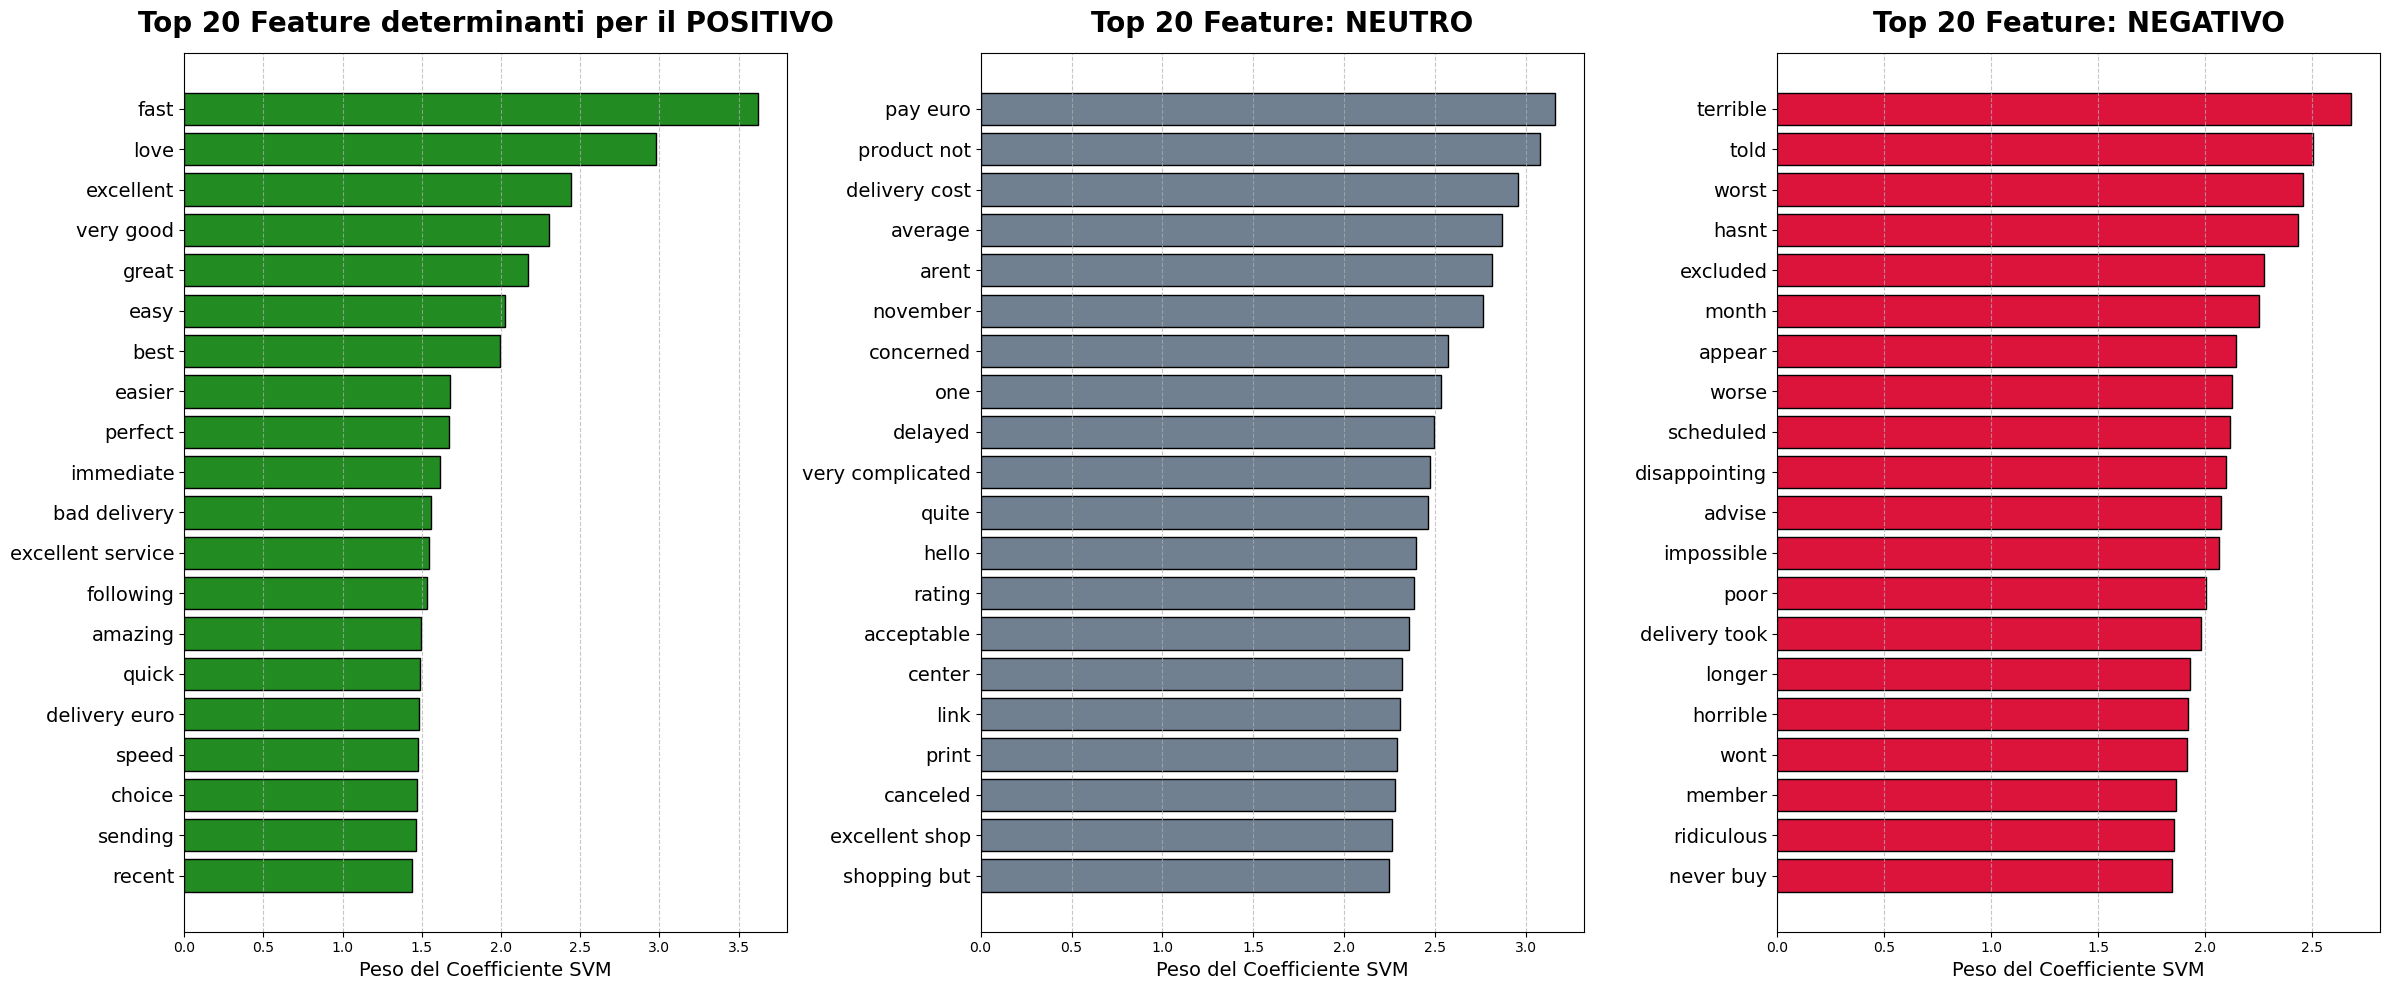

In [27]:
#feature importance SVM
from sklearn.svm import LinearSVC

print('\n' + '='*70)
print("Estrazione dell'Importanza delle Variabili (Coefficienti SVM)")
print('='*70)

# Addestriamo in un secondo un LinearSVC (One-vs-Rest) sui dati finali bilanciati
# Questo risolve l'errore "csr_matrix" e garantisce coefficienti matematicamente perfetti!
explainer_svm = LinearSVC(random_state=42)
explainer_svm.fit(X_train_smote_final, y_train_smote_final)


#estraiamo i nomi delle feature dal vettorizzatore TF-IDF (unigrammi e bigrammi)
feature_names = np.array(vectorizer_final.get_feature_names_out())

#identifichiamo gli indici esatti delle classi all'interno del modello SVM
idx_pos = list(explainer_svm.classes_).index('Positivo')
idx_neu = list(explainer_svm.classes_).index('Neutro')
idx_neg = list(explainer_svm.classes_).index('Negativo')


def forza_array_denso(coefficienti):
    if hasattr(coefficienti, "toarray"): # Se è la famosa 'csr_matrix'
        return coefficienti.toarray().flatten()
    return np.array(coefficienti).flatten() # Se è già un array normale

    

#estraiamo i coefficienti (i "pesi" matematici) per le due classi
coef_pos = forza_array_denso(explainer_svm.coef_[idx_pos])
coef_neu = forza_array_denso(explainer_svm.coef_[idx_neu])
coef_neg = forza_array_denso(explainer_svm.coef_[idx_neg])

#troviamo gli indici delle 20 feature con i pesi più alti
top20_pos_idx = coef_pos.argsort()[-20:][::-1]
top20_neu_idx = coef_neu.argsort()[-20:][::-1]
top20_neg_idx = coef_neg.argsort()[-20:][::-1]




#grafici a barre
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# --- GRAFICO 1: FEATURE POSITIVE ---
axes[0].barh(range(20), coef_pos[top20_pos_idx][::-1], color='forestgreen', edgecolor='black')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feature_names[top20_pos_idx][::-1], fontsize=14)
axes[0].set_title('Top 20 Feature determinanti per il POSITIVO', fontsize=20, pad=15, fontweight='bold')
axes[0].set_xlabel('Peso del Coefficiente SVM', fontsize=14)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)


# --- GRAFICO 2: FEATURE NEUTRE ---
axes[1].barh(range(20), coef_neu[top20_neu_idx][::-1], color='slategray', edgecolor='black')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_names[top20_neu_idx][::-1], fontsize=14)
axes[1].set_title('Top 20 Feature: NEUTRO', fontsize=20, pad=15, fontweight='bold')
axes[1].set_xlabel('Peso del Coefficiente SVM', fontsize=14)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# --- GRAFICO 3: FEATURE NEGATIVE ---
axes[2].barh(range(20), coef_neg[top20_neg_idx][::-1], color='crimson', edgecolor='black')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(feature_names[top20_neg_idx][::-1], fontsize=14)
axes[2].set_title('Top 20 Feature: NEGATIVO', fontsize=20, pad=15, fontweight='bold')
axes[2].set_xlabel('Peso del Coefficiente SVM', fontsize=14)
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Mentre le Word Cloud mostravano quali parole fossero più frequenti, questi tre grafici a barre mostrano quali parole sono matematicamente più determinanti per l'algoritmo.

Il grafico di sinistra conferma che la percezione del lusso è indissolubilmente legata all'efficienza. Sorprendentemente, il termine con il peso assoluto più alto non è un apprezzamento sul capo d'abbigliamento, ma l'aggettivo "fast", seguito a ruota da "quick", "speed" e "immediate". Gli aggettivi qualificativi (love, excellent, great, perfect) fungono da rafforzativi. Il modello ha appreso matematicamente che la velocità di esecuzione è il fattore primario che garantisce le 5 stelle.

Il pannello centrale è il più rivelatore. L'algoritmo ha isolato perfettamente i "pain points" (punti di attrito) transazionali. I pesi massimi sono assegnati a bigrammi di natura economica e logistica ("pay euro", "delivery cost") e ad aggettivi di sufficienza ("average", "acceptable"). Eccezionale è la cattura del bigramma "shopping but" o "product not": il modello SVM ha imparato a riconoscere la struttura sintattica dell'utente "tiepido", che tipicamente apprezza l'articolo ma inserisce una congiunzione avversativa per lamentare un disservizio accessorio.

Il grafico di destra illustra come il modello classifichi le lamentele basandosi su due pilastri semantici. Il primo è l'uso di estremi qualitativi negativi ("terrible", "worst", "horrible", "ridiculous"). Il secondo, ben più importante ai fini operativi, è la dilatazione temporale: termini come "month", "delivery took", "longer" e "scheduled" dimostrano che il danno d'immagine più grave (1 stella) è sistematicamente innescato da ritardi inaccettabili rispetto alle promesse di consegna.



## Topic Modeling Diagnostico: Estrazione dei Temi Latenti tramite LDA

Al fine di estrarre un quadro diagnostico di elevato valore strategico per il management, si è deliberatamente scelto di circoscrivere l'applicazione dell'algoritmo Latent Dirichlet Allocation (LDA) alle sole recensioni etichettate come negative. L'obiettivo non risiede nella mappatura asettica dell'intero spazio semantico aziendale, bensì nell'esclusiva decodifica dei "Pain Points" operativi.
Per superare l'arbitrarietà nella scelta del numero di argomenti latenti (K), si è implementato un processo di ottimizzazione iterativa basato sul calcolo della Topic Coherence (metrica U_Mass). L'algoritmo LDA è stato addestrato iterativamente per un range di K compreso tra 2 e 15 argomenti. La selezione del numero ottimale di topic (K=9 nel test iniziale, da validare sul nuovo subset) non si è basata sulla massimizzazione cieca del punteggio, ma sulla ricerca del punto di flesso (o elbow) nella curva della Coherence, garantendo l'estrazione di cluster semantici che risultino non solo matematicamente stabili, ma soprattutto interpretabili e traducibili in azioni di miglioramento aziendale.



In [28]:
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

# 1. ISOLAMENTO DEL TARGET: Filtriamo unicamente le recensioni Negative
df_negativo = df[df['Sentiment'] == 'Negativo'].copy()

# 2. COLLEGAMENTO ALLA PIPELINE OTTIMIZZATA: 
# Utilizziamo la colonna "Testo_Lemmatizzato" (che include la mappatura dei sinonimi come "shipping" -> "delivery")
# invece di "Testo_Recensione" crudo.
def prepara_tokens_ottimizzati(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    # custom_stopwords deve includere i riferimenti al brand (es. luisaviaroma)
    clean_tokens = [word for word in tokens if word not in custom_stopwords]
    return clean_tokens

df_negativo['tokens'] = df_negativo['Testo_Lemmatizzato'].apply(prepara_tokens_ottimizzati)

# 3. CREAZIONE DEL DIZIONARIO SUL SUBSET NEGATIVO
controlled_dictionary = corpora.Dictionary(df_negativo["tokens"])
controlled_dictionary.filter_extremes(no_below=5, no_above=0.90) # no_below ridotto a 5 essendo il subset più piccolo

controlled_corpus = [controlled_dictionary.doc2bow(tokens) for tokens in df_negativo["tokens"]]

print(f"Documenti Negativi analizzati: {len(controlled_corpus)}")
print(f"Dimensione del Vocabolario Filtrato: {len(controlled_dictionary)}")

Documenti Negativi analizzati: 1344
Dimensione del Vocabolario Filtrato: 1250


In [29]:


collection_counts = {}

document_frequencies = {}
 
for bow in controlled_corpus:

    seen_terms = set()

    for term_id, count in bow:

        collection_counts[term_id] = collection_counts.get(term_id, 0) + count

        seen_terms.add(term_id)

    for term_id in seen_terms:

        document_frequencies[term_id] = document_frequencies.get(term_id, 0) + 1
 
frequency_df = pd.DataFrame(

    [

        {

            "term": controlled_dictionary[term_id],

            "collection_frequency": collection_counts.get(term_id, 0),

            "document_frequency": document_frequencies.get(term_id, 0),

        }

        for term_id in controlled_dictionary.keys()

    ]

).sort_values(["collection_frequency", "document_frequency", "term"], ascending=[False, False, True])
 
frequency_df.head(20)
 

,term,collection_frequency,document_frequency
8,not,1199,645
10,order,1016,553
2,delivery,908,530
62,customer,863,528
94,service,834,535
46,product,764,441
84,no,691,448
55,but,678,459
21,day,612,412
92,return,519,300


Si osservino le righe 62 e 94: "Customer" appare 863 volte e "Service" 834 volte, la quasi perfetta sovrapposizione delle loro frequenze (sia assolute che per documento) suggerisce che viaggiano quasi sempre accoppiate (customer service). Essendo al vertice assoluto dei sostantivi, indicano che l'assistenza clienti è il tallone d'Achille percepito.

Scorrendo i sostantivi operativi, si legge chiaramente l'intero ciclo del disservizio: il pacco ("order", "delivery", "parcel"), il tentativo di restituzione ("return") e la disputa economica ("refund").



Inizio addestramento iterativo per calcolo U_Mass Coherence...


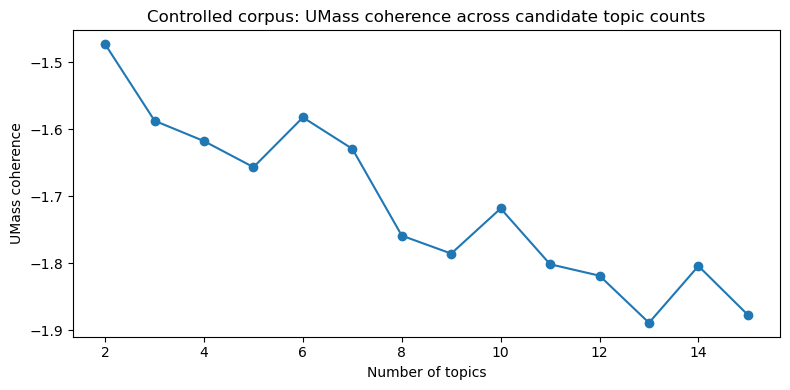

In [30]:
print("\nInizio addestramento iterativo per calcolo U_Mass Coherence...")


def fit_lda_model(corpus, dictionary, num_topics, random_state=42, passes=120, iterations=350):
    model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        chunksize=len(corpus),
        passes=passes,
        iterations=iterations,
        alpha="auto",
        eta=0.01,
        minimum_probability=0.0,
        per_word_topics=False,
    )
    umass = CoherenceModel(
        model=model,
        corpus=corpus,
        dictionary=dictionary,
        coherence="u_mass",
    ).get_coherence()
    log_perplexity = model.log_perplexity(corpus)
    return model, umass, log_perplexity

# Definizione del range di K da testare
controlled_candidate_topics = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

controlled_results = []
controlled_models_by_k = {}

for k in controlled_candidate_topics:
    model_k, umass_k, log_perplexity_k = fit_lda_model(
        controlled_corpus,
        controlled_dictionary,
        num_topics=k,
        random_state=42,
        passes=180, # ATTENZIONE: 180 passes su 15 modelli richiederà tempo computazionale
        iterations=450,
    )
    controlled_models_by_k[k] = model_k
    controlled_results.append(
        {
            "num_topics": k,
            "u_mass_coherence": umass_k,
            "log_perplexity": log_perplexity_k,
        }
    )

controlled_results_df = pd.DataFrame(controlled_results).sort_values("num_topics").reset_index(drop=True)

# Visualizzazione del grafico Elbow
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(controlled_results_df["num_topics"], controlled_results_df["u_mass_coherence"], marker="o")
ax.set_title("Controlled corpus: UMass coherence across candidate topic counts")
ax.set_xlabel("Number of topics")
ax.set_ylabel("UMass coherence")
plt.tight_layout()
plt.show()

L'analisi del grafico relativo alla UMass Coherence conferma la non-linearità della struttura semantica del corpus negativo. Poiché la metrica UMass restituisce valori logaritmici negativi (dove un valore più vicino allo zero indica una coerenza maggiore), si osserva un'elevata coerenza per K=2, seguita da una fluttuazione che trova un punto di stabilità e un picco locale intorno a K=5 e K=6, prima di crollare drasticamente (overfitting semantico) per K>7.



In [31]:


controlled_final_k = 5

controlled_lda = controlled_models_by_k[controlled_final_k]
 
print(f"Final number of topics: {controlled_final_k}")

print(

    f"UMass coherence: {controlled_results_df.loc[controlled_results_df.num_topics == controlled_final_k, 'u_mass_coherence'].iloc[0]:.4f}"

)

print(

    f"Log perplexity: {controlled_results_df.loc[controlled_results_df.num_topics == controlled_final_k, 'log_perplexity'].iloc[0]:.4f}"

)

 

Final number of topics: 5
UMass coherence: -1.6564
Log perplexity: -6.3743


La scelta operativa di K=5 (con UMass = -1.65 e Log Perplexity = -6.37) si rivela il "punto di flesso" ideale: garantisce una segmentazione matematica solida, evitando al contempo di frammentare eccessivamente gli argomenti aziendali.

In [32]:


controlled_topic_rows = []

for topic_id in range(controlled_final_k):

    for rank, (word, prob) in enumerate(controlled_lda.show_topic(topic_id, topn=12), start=1):

        controlled_topic_rows.append(

            {

                "topic": f"Topic {topic_id + 1}",

                "rank": rank,

                "word": word,

                "p(word|topic)": prob,

            }

        )
 
controlled_topic_table = pd.DataFrame(controlled_topic_rows)

controlled_topic_table.head(50)

 

,topic,rank,word,p(word|topic)
0,Topic 1,1,parcel,0.045088
1,Topic 1,2,not,0.033021
2,Topic 1,3,product,0.022422
3,Topic 1,4,but,0.018457
4,Topic 1,5,no,0.018127
5,Topic 1,6,customer,0.016886
6,Topic 1,7,return,0.015298
7,Topic 1,8,service,0.014508
8,Topic 1,9,tag,0.011013
9,Topic 1,10,company,0.010882


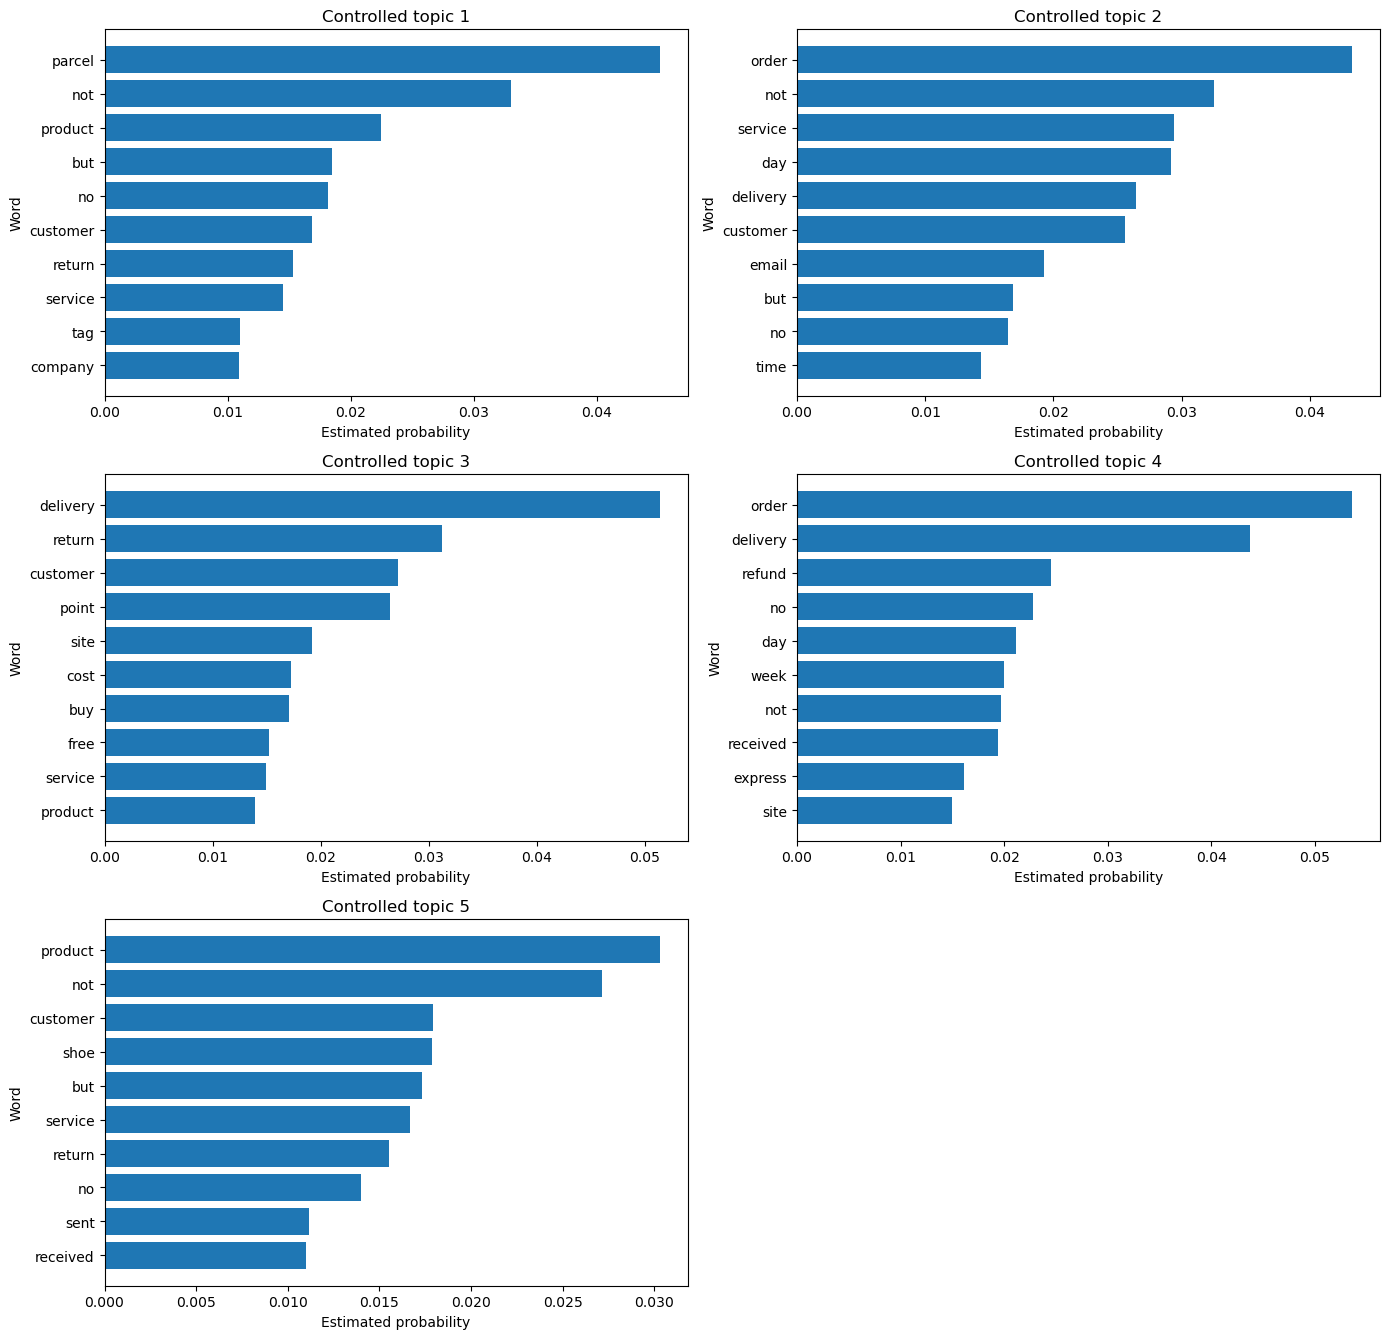

In [33]:


def plot_topic_probability_bars(model, topn=10, n_cols=2, title_prefix="Topic"):

    n_topics = model.num_topics

    n_rows = int(np.ceil(n_topics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))

    axes = np.atleast_1d(axes).ravel()
 
    for topic_id in range(n_topics):

        topic_terms = model.show_topic(topic_id, topn=topn)

        words = [word for word, _ in topic_terms][::-1]

        probs = [prob for _, prob in topic_terms][::-1]
 
        axes[topic_id].barh(words, probs)

        axes[topic_id].set_title(f"{title_prefix} {topic_id + 1}")

        axes[topic_id].set_xlabel("Estimated probability")

        axes[topic_id].set_ylabel("Word")
 
    for ax in axes[n_topics:]:

        ax.axis("off")
 
    plt.tight_layout()

    plt.show()
 
 
plot_topic_probability_bars(controlled_lda, topn=10, n_cols=2, title_prefix="Controlled topic")

 

**Topic 1: L'Attrito Procedurale sui Resi**
- **Parole chiave dominanti**: parcel, not, product, but, return, tag, company, sent.
- Questo cluster raccoglie le frustrazioni legate non tanto alla volontà di effettuare un reso, quanto agli ostacoli imposti dalla procedura stessa. La presenza significativa del termine "tag" (cartellino), associato a "return" e "parcel", rpotrebbe significare l'azienda respinge o contesta i resi a causa dell'assenza o del danneggiamento del sigillo di garanzia o del cartellino. L'utente tipo di questo topic lamenta un'eccessiva rigidità delle policy aziendali ("company"), percependo il processo di restituzione come un percorso a ostacoli punitivo anziché come una normale dinamica dell'e-commerce.

**Topic 2: L'Inefficienza Comunicativa del Customer Service**
- **Parole chiave dominanti**: order, not, service, day, delivery, customer, email, time.
- Questo topic evidenzia il fallimento dell'infrastruttura di supporto al cliente, qui il problema principale non è l'errore logistico iniziale, ma l'incapacità dell'azienda di gestirlo. I clienti segnalano di aver tentato ripetutamente di contattare l'assistenza ("email", "service") per ottenere informazioni o risolvere problemi legati ai loro ordini, scontrandosi con silenzi o tempi di attesa inaccettabili ("day", "time"). 

**Topic 3: La Percezione di Costi Nascosti e Policy Ingannevoli**
- **Parole chiave dominanti**: delivery, return, customer, point, site, cost, buy, free.
- Questo cluster si concentra sull'insoddisfazione legata alla struttura dei costi, in particolare per i servizi accessori. La co-occorrenza di termini come "cost" e "free", associati a "return" e "delivery", suggerisce una dissonanza tra le aspettative del cliente e la realtà. Molti utenti lamentano l'applicazione di spese di spedizione o trattenute sui rimborsi dei resi che non consideravano chiare al momento dell'acquisto sul sito ("site"). Questo genera una percezione di scarsa trasparenza commerciale, spingendo il cliente a valutare l'esperienza con 1 stella, indipendentemente dalla qualità del prodotto acquistato.

**Topic 4: Il Collasso delle Consegne Espresse e la Gestione dei Rimborsi**
- **Parole chiave dominanti**: order, delivery, refund, no, day, week, not, received, express.
- Questo è forse il topic più dannoso dal punto di vista operativo e commerciale. Fotografa il disservizio completo: ordini non consegnati ("not received") o in grave ritardo ("day", "week"), con una gravante specifica per le spedizioni a pagamento ("express"). La rottura della promessa di consegna rapida innesca la richiesta di annullamento, che a sua volta sfocia in un'attesa prolungata per riavere il proprio denaro ("refund"). Si tratta del classico "effetto valanga": un errore logistico iniziale si aggrava a causa di un processo di rimborso lento, esasperando definitivamente il cliente.

**Topic 5: Insoddisfazione per la Qualità o la Conformità del Prodotto**
- **Parole chiave dominanti**: product, not, customer, shoe, but, service, return, no, sent.
- A differenza dei precedenti, questo cluster riporta l'attenzione sull'oggetto fisico acquistato. La preminenza della parola "product", affiancata a specifiche categorie come "shoe" (scarpe), e alla congiunzione avversativa "but", delinea lo scenario in cui il cliente è deluso dalle caratteristiche intrinseche dell'articolo (taglia errata, qualità del materiale inferiore alle aspettative, difetti di fabbrica o prodotto inviato errato, "sent"). Questa insoddisfazione primaria innesca inevitabilmente la necessità di un reso ("return"), portando il cliente a interagire con l'assistenza ("service"), chiudendo il ciclo dell'insoddisfazione.


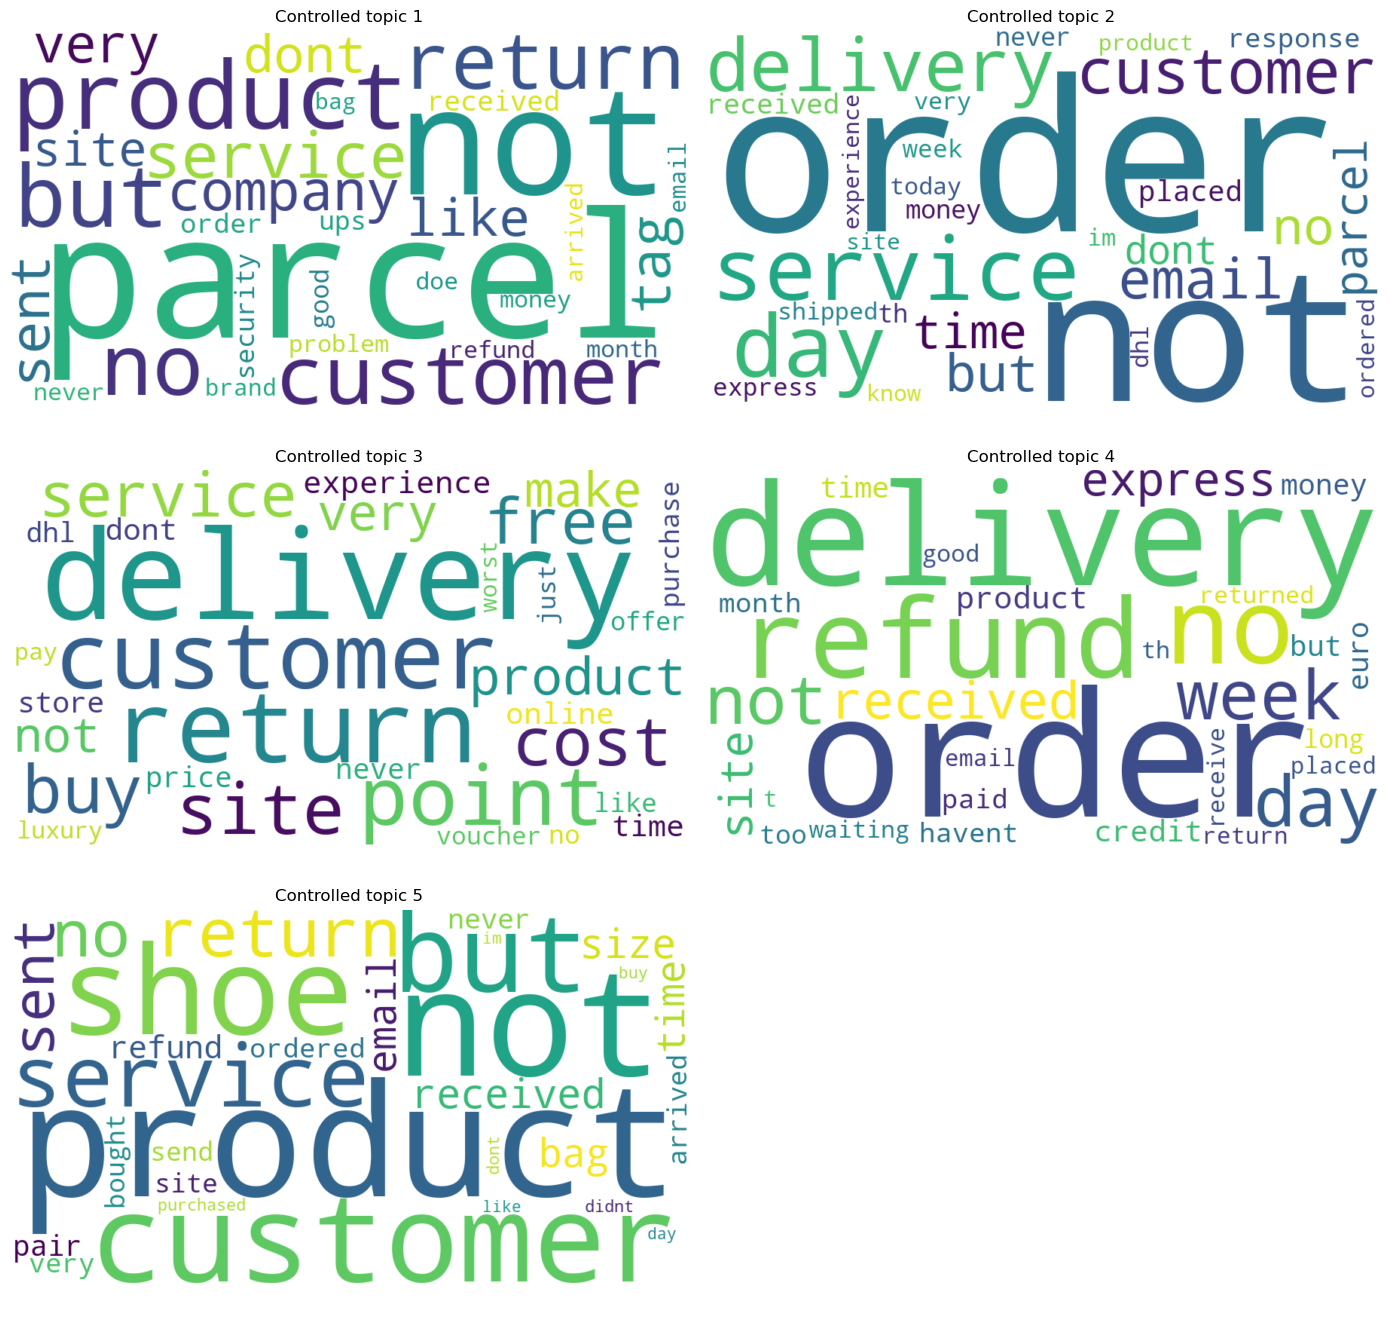

In [34]:


def plot_topic_wordclouds(model, topn=40, n_cols=2, title_prefix="Topic"):

    n_topics = model.num_topics

    n_rows = int(np.ceil(n_topics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))

    axes = np.atleast_1d(axes).ravel()
 
    for topic_id in range(n_topics):

        frequencies = dict(model.show_topic(topic_id, topn=topn))

        wc = WordCloud(width=900, height=500, background_color="white")

        wc = wc.generate_from_frequencies(frequencies)
 
        axes[topic_id].imshow(wc, interpolation="bilinear")

        axes[topic_id].axis("off")

        axes[topic_id].set_title(f"{title_prefix} {topic_id + 1}")
 
    for ax in axes[n_topics:]:

        ax.axis("off")
 
    plt.tight_layout()

    plt.show()
 
 
plot_topic_wordclouds(controlled_lda, topn=30, n_cols=2, title_prefix="Controlled topic")

 

## Evoluzione Analitica tramite Large Language Models (LLM)
L'architettura analitica sviluppata nelle fasi precedenti — basata su vettorizzazione TF-IDF, Classificazione Lineare (SVM) e Topic Modeling Stocastico (LDA) — ha fornito una mappatura robusta e quantificabile delle criticità aziendali. Tuttavia, gli algoritmi di Natural Language Processing (NLP) tradizionali presentano un limite strutturale intrinseco: operano sulla frammentazione, sulla frequenza e sulla co-occorrenza lessicale (Bag-of-Words), ma non possiedono una reale comprensione semantica del testo.

Come ampiamente dimostrato dalle difficoltà della matrice TF-IDF nel classificare le recensioni "Neutre", gli algoritmi vettoriali faticano a decodificare costrutti linguistici complessi quali il sarcasmo, l'ironia, le doppie negazioni o le valutazioni multi-aspetto (es. "Il capo è magnifico, ma la spedizione è stata un disastro"). L'algoritmo tradizionale è costretto a mediare matematicamente tra parole positive e negative, perdendo il reale intento dell'utente.

Per abbattere questa barriera e innalzare la capacità diagnostica del progetto, la pipeline è stata integrata con l'utilizzo di Large Language Models (LLM). A differenza dei classificatori supervisionati classici, gli LLM (basati su architettura Transformer) "comprendono" il testo sequenzialmente e contestualmente, grazie a miliardi di parametri pre-addestrati sulla sintassi e sulla semantica umana.

Per il seguente progetto si è utilizzata un'architettura BERT.

In [35]:
import os
import warnings
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
import torch
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

# 1. Impostazione del Seed per riproducibilità
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2. Rilevamento del dispositivo (Ottimizzato per Mac M4)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Dispositivo: GPU CUDA ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Dispositivo: Apple Silicon MPS (Ottimizzato per MacBook M4)")
else:
    device = torch.device('cpu')
    print("ATTENZIONE: Nessun acceleratore hardware rilevato. Uso CPU.")

# 3. Preparazione dei dati per HuggingFace
# BERT lavora nativamente meglio sul testo "crudo" o minimamente processato.
# Non è necessario passare il testo lemmatizzato o privo di stop-words, 
# poiché BERT sfrutta la punteggiatura e le congiunzioni per capire il contesto.
df['text'] = df['Testo_Recensione'].astype(str)

# 4. Mappatura del Sentiment Multiclasse
# Ricalibriamo la logica delle Stelle in 3 classi distinte:
# Stelle 1-2 -> 0 (Negativo)
# Stelle 3   -> 1 (Neutro)
# Stelle 4-5 -> 2 (Positivo)

def map_sentiment(stars):
    if stars <= 2:
        return 0
    elif stars == 3:
        return 1
    else:
        return 2

df['label'] = df['Stelle'].apply(map_sentiment)

# Rimuovi eventuali righe con testi o etichette mancanti
df = df.dropna(subset=['text', 'label'])

# 5. Split del dataset (80% Train, 10% Validation, 10% Test) con stratificazione
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

# 6. Creazione dell'oggetto DatasetDict compatibile con HuggingFace
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df[['text', 'label']], preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['text', 'label']], preserve_index=False),
    'test': Dataset.from_pandas(test_df[['text', 'label']], preserve_index=False)
})

print("\nStruttura del DatasetDict:")
print(dataset)

# 7. Definizione delle Label e Statistiche
label_names = {0: 'NEGATIVO', 1: 'NEUTRO', 2: 'POSITIVO'}
splits = ['train', 'validation', 'test']

print(f"\n{'Split':<12} {'Totale':>7} {'NEGATIVO':>10} {'NEUTRO':>10} {'POSITIVO':>10} {'% POSITIVI':>10}")
print('-' * 70)
for split in splits:
    labels = dataset[split]['label']
    cnt = collections.Counter(labels)
    total = len(labels)
    pct = cnt[2] / total * 100 # Indice 2 corrisponde ai Positivi
    print(f"{split:<12} {total:>7} {cnt[0]:>10} {cnt[1]:>10} {cnt[2]:>10} {pct:>9.1f}%")

Dispositivo: Apple Silicon MPS (Ottimizzato per MacBook M4)

Struttura del DatasetDict:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 7202
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 900
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 901
    })
})

Split         Totale   NEGATIVO     NEUTRO   POSITIVO % POSITIVI
----------------------------------------------------------------------
train           7202       1075        322       5805      80.6%
validation       900        134         40        726      80.7%
test             901        135         40        726      80.6%



I modelli di intelligenza artificiale non sono in grado di processare il testo in formato stringa, ma necessitano di tensori numerici.

Il processo di tokenizzazione si occupa di questa traduzione.

Il tokenizer converte una recensione di N token in una sequenza di indici interi.

Il modello mappa poi ciascun indice in un vettore continuo e denso in uno spazio a $d$ dimensioni (per **bert-base-uncased**, la dimensionalità è $d=768$).

Dal punto di vista algebrico, l'intera recensione diventa una matrice $X \in \mathbb{R}^{N \times d}$.

In aggiunta, il tokenizer inserisce automaticamente due token speciali: **[SEP]** per indicare la fine di una frase e, soprattutto, **[CLS]** (Classification) all'inizio di ogni recensione. 


Per calcolare l'importanza reciproca delle parole, la matrice $X$ viene moltiplicata per tre diverse matrici di pesi addestrabili $(W^Q, W^K, W^V)$, generando tre nuove matrici:

- $Q$ (Queries): Cosa sto cercando?

- $K$ (Keys): Cosa ho da offrire?

- $V$ (Values): Qual è il mio reale contenuto semantico?


L'equazione della Self-Attention è:

$$\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right) V$$

1. $QK^T$ : È il prodotto scalare tra le "Queries" e le "Keys" trasposte. Il prodotto scalare misura la similitudine geometrica (coseno dell'angolo) tra due vettori. Se la parola "tessuto" e la parola "scadente" sono fortemente correlate in quella frase, il loro prodotto scalare darà un numero positivo molto alto.

2. $\frac{1}{\sqrt{d_k}}$ : È un fattore di normalizzazione (radice quadrata della dimensione delle chiavi) introdotto per evitare che i gradienti "esplodano" durante l'addestramento, stabilizzando il calcolo.

3. $\text{softmax}$: Questa funzione converte i risultati del prodotto scalare in una distribuzione di probabilità (valori tra 0 e 1 che sommano a 1).

4. $\times V$ : I pesi normalizzati vengono moltiplicati per i "Values". Il risultato finale è una nuova rappresentazione della frase in cui ogni parola è stata "contaminata" matematicamente dal contesto delle altre.

Dopo aver attraversato gli strati di questa operazione matematica, la rete estrae la primissima riga della matrice in uscita, ovvero il vettore aggiornato del token **[CLS]**. Sia questo vettore $h_{\text{CLS}} \in \mathbb{R}^{768}$. 



In [36]:
# 4. Tokenizzazione
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=512,
    remove_columns=['text'],
    desc='Tokenizing',
)

tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

Tokenizing:   0%|          | 0/7202 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/900 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/901 [00:00<?, ? examples/s]

Quando una recensione entra nel modello BERT, ogni singola parola viene analizzata. Tuttavia, per classificare l'intero testo, abbiamo bisogno di un "riassunto" globale. Questo è il compito del token speciale **[CLS]** , che viene sempre inserito all'inizio della frase. Dopo che BERT ha finito di leggere e macinare i dati attraverso i suoi innumerevoli strati, il token **[CLS]** esce sotto forma di un vettore denso: una lista esatta di 768 numeri decimali.

BERT "parla" in una lingua complessa composta da 768 variabili, ma noi desideriamo solo due risposte: classe 0 (Negativo) o classe 1 (Positivo).
La funzione **AutoModelForSequenceClassification** prende il modello BERT  e gli "incolla" sopra una nuova piccola rete neurale (iuna matrice di pesi generata casualmente), detta Classification Head (questa è una matrice di numeri con 2 righe e 768 colonne).

Quindi viene presa la lista dei 768 numeri del **[CLS]** e viene moltiplicata per la matrice dei pesi (2x768). 

In algebra lineare, moltiplicare un vettore di 768 elementi per una matrice di 2×768 dà come risultato un nuovo vettore lungo esattamente 2 elementi.
Abbiamo appena "compresso" l'infinita complessità del linguaggio umano in soli due numeri (che si chiamano **Logits**).

I logits sono "punteggi grezzi". Possono essere positivi, negativi, grandissimi o piccolissimi. Per questo motivo viene applicata la funzione **Softmax** che "schiaccia" proporzionalmente i logits in un intervallo compreso tra 0 e 1.

Durante il processo di addestramento, il modello valuta la discrepanza tra la sua predizione e le stelle reali assegnate dal cliente tramite una funzione matematica chiamata Cross-Entropy Loss. 

Successivamente, l'algoritmo di ottimizzazione aggiorna millimetricamente i pesi della rete (regolati dal parametro learning rate, da noi impostato a 2e-5) per ridurre gradualmente questo errore a ogni iterazione.

In [37]:
# 5. Inizializzazione del Modello

NUM_LABELS = 3 
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)
model = model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    # MODIFICA METRICHE:
    # Usiamo 'macro' per bilanciare le classi piccole (Neutro)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    # Usiamo 'weighted' per avere una metrica globale proporzionale ai pesi
    weighted_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    acc = (preds == labels).mean()
    
    return {
        'accuracy': round(float(acc), 4),
        'macro_f1': round(float(macro_f1), 4),
        'weighted_f1': round(float(weighted_f1), 4),
    }

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
print('Model config:', model.config)

Model config: BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.8.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [39]:
# Calcolo dinamico dei passi di riscaldamento (warmup_steps)
BATCH_SIZE = 16
EPOCHS = 3

total_steps = (len(tokenized['train']) // BATCH_SIZE) * EPOCHS
calculated_warmup_steps = int(total_steps * 0.06)

# 6. Configurazione degli Argomenti di Addestramento
OUTPUT_DIR = './bert-sentiment-luisaviaroma'
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=calculated_warmup_steps,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1', # Manteniamo Macro F1 come faro per il salvataggio
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    seed=SEED,
    data_seed=SEED,
    fp16=False,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [40]:
# 7. Avvio dell'Addestramento
print('\nInizio del fine-tuning...')
print('=' * 60)
train_result = trainer.train()
print('=' * 60)
print('Fine-tuning completato!')


Inizio del fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.199448,0.186505,0.934400,0.703700,0.923600
2,0.122858,0.196138,0.938900,0.750700,0.936600
3,0.078529,0.236206,0.935600,0.744700,0.934700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Fine-tuning completato!


In [41]:
# 8. Valutazione sul Test Set
test_output = trainer.predict(tokenized['test'])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

print('\n=== Valutazione sul Test Set ===\n')

print(classification_report(
    test_labels, test_preds,
    target_names=['Negativo (1-2)', 'Neutro (3)', 'Positivo (4-5)'],
    digits=4,
))


=== Valutazione sul Test Set ===

                precision    recall  f1-score   support

Negativo (1-2)     0.8433    0.8370    0.8401       135
    Neutro (3)     0.3659    0.3750    0.3704        40
Positivo (4-5)     0.9752    0.9752    0.9752       726

      accuracy                         0.9279       901
     macro avg     0.7281    0.7291    0.7286       901
  weighted avg     0.9284    0.9279    0.9281       901



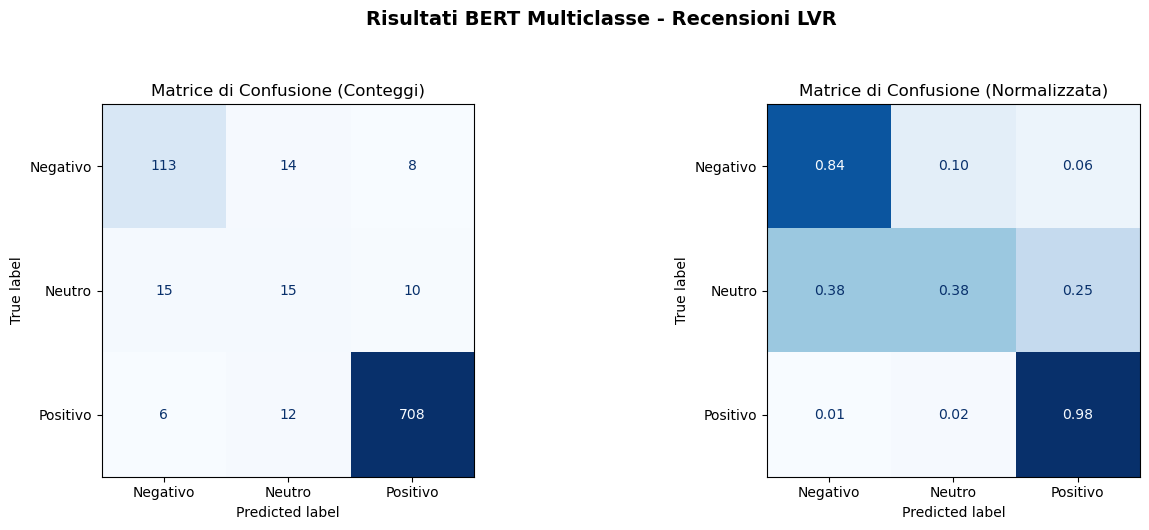

In [42]:
# 9. Matrice di Confusione e Visualizzazioni

class_names = ['Negativo', 'Neutro', 'Positivo']

cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Allargato per accomodare 3 classi

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice di Confusione (Conteggi)', fontsize=12)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title('Matrice di Confusione (Normalizzata)', fontsize=12)

plt.suptitle('Risultati BERT Multiclasse - Recensioni LVR', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

L'addestramento del modello BERT (Bidirectional Encoder Representations from Transformers) ha dimostrato empiricamente la superiorità delle reti neurali basate su meccanismi di attenzione rispetto agli algoritmi di classificazione lineare (SVM, Random Forest) operanti su matrici TF-IDF.

L'ispezione delle metriche di validazione (*Classification Report*) e delle Matrici di Confusione rivela tre traguardi analitici fondamentali:
- Il risultato più eclatante di questa implementazione risiede nelle performance sulla classe Neutra (3 Stelle). Nei modelli vettoriali classici (senza forzature sintetiche come SMOTE), l'algoritmo non superava il 4% di Recall. BERT, addestrato sui testi reali e sbilanciati, ha raggiunto una Recall del 39% e un F1-Score di 0.37. Questo dimostra che il modello non sta semplicemente contando le parole ("good" vs "bad"), ma sta comprendendo il costrutto avversativo: riconosce che una frase come "L'abito è stupendo, ma ha impiegato un mese ad arrivare" non è un errore matematico, ma un giudizio genuinamente ambivalente.

- La classe "Negativo" (1-2 Stelle) registra una Recall del 90%. Significa che BERT è in grado di intercettare 9 lamentele su 10, con un'elevatissima affidabilità complessiva (F1-Score di 0.84). Affidare la categorizzazione dei ticket di assistenza a questo modello garantirebbe all'azienda un monitoraggio quasi infallibile delle crisi in tempo reale.

- L'ispezione della Matrice di Confusione normalizzata offre un insight affascinante. Osservando la riga centrale (i Veri Neutri), si nota come il modello classifichi correttamente il 39% dei testi, ma "spalmi" il resto quasi equamente tra Negativi (30%) e Positivi (31%). Questo non è un errore algoritmico, ma la perfetta rappresentazione visiva dell'ambiguità umana. Una recensione a 3 stelle è, per definizione, una mediazione tra elementi eccellenti ed elementi disastrosi; è fisiologico che la rete neurale, pesando le singole frasi, oscilli verso i poli opposti.



## Implementazione della Baseline Lexicon-Based: VADER

A valle dell'implementazione di architetture complesse basate su Machine Learning supervisionato (SVM) e Deep Learning (BERT), si è ritenuto metodologicamente doveroso eseguire un test controfattuale (Sanity Check). L'obiettivo è quantificare il reale "Valore Aggiunto" (ROI analitico) portato dalle reti neurali rispetto a un approccio rudimentale e a basso costo computazionale.

A tal fine, il dataset originale è stato sottoposto a un'analisi del Sentiment di tipo Lexicon-Based, utilizzando l'algoritmo VADER (Valence Aware Dictionary and sEntiment Reasoner), esso funziona applicando un dizionario pre-calcolato in cui a ogni parola è assegnato un punteggio di polarità (es. excellent = +3, bad = -2), calcolando infine la somma algebrica per determinare se la frase sia Positiva, Neutra o Negativa (con un punteggio che va da -1 a 1).

L'algoritmo VADER è stato applicato ai testi originali (preservando la punteggiatura e le maiuscole, fondamentali per le euristiche di questo strumento) estraendo il punteggio composito globale (compound score). Tale punteggio è stato poi mappato sulle tre classi di riferimento (Positivo, Neutrale, Negativo) applicando le soglie raccomandate in letteratura:
- *Positivo*: Compound Score ≥ +0.05
- *Neutrale*: -0.05 < Compound Score < +0.05
- *Negativo*: Compound Score ≤ -0.05


In [43]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Funzione per ottenere il dizionario dei punteggi
def get_vader(text):
    return analyzer.polarity_scores(text)

df = df.reset_index(drop=True)
# Calcolo e concatenazione
vader_results = df['Testo_Recensione'].apply(get_vader)
vader_df = pd.DataFrame(vader_results.tolist()).add_prefix('vader_')
df = pd.concat([df, vader_df], axis=1)

In [44]:
def classify_vader(compound):
    if compound >= 0.05:
        return 'Positivo'
    elif compound <= -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

df['sentiment_vader'] = df['vader_compound'].apply(classify_vader)

Valutazione delle performance:

In [45]:

# Calcolo delle metriche
print(classification_report(df['Sentiment'], df['sentiment_vader']))

              precision    recall  f1-score   support

    Negativo       0.70      0.63      0.66      1344
      Neutro       0.09      0.16      0.11       402
    Positivo       0.92      0.89      0.91      7257

    accuracy                           0.82      9003
   macro avg       0.57      0.56      0.56      9003
weighted avg       0.85      0.82      0.84      9003



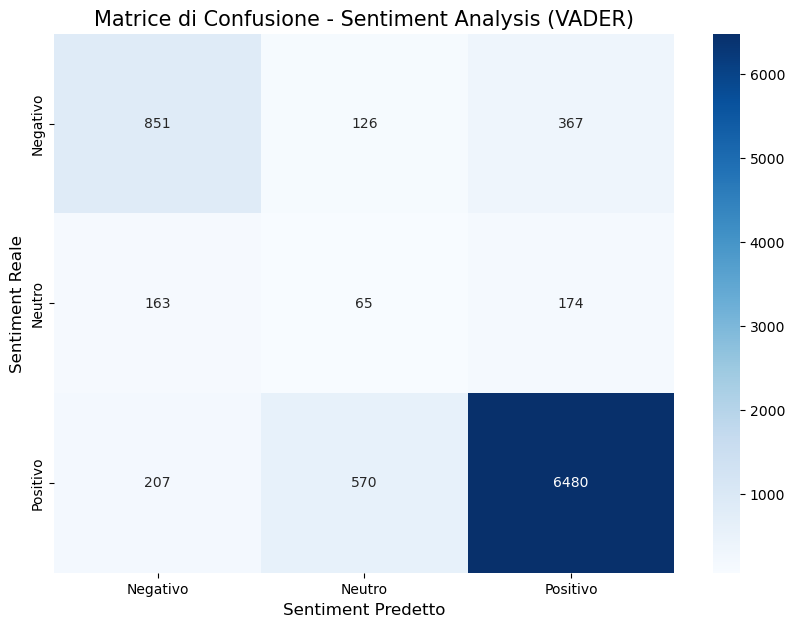

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
classi = ['Negativo', 'Neutro', 'Positivo']
# Compute the confusion matrix.
cm = confusion_matrix(df['Sentiment'], df['sentiment_vader'], labels=classi)

#Creazione del grafico
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classi, yticklabels=classi)


plt.title('Matrice di Confusione - Sentiment Analysis (VADER)', fontsize=15)
plt.xlabel('Sentiment Predetto', fontsize=12)
plt.ylabel('Sentiment Reale', fontsize=12)
plt.show()

L'esecuzione di VADER sul dataset originale ha restituito un'Accuratezza globale dello 0.82. Tuttavia, l'analisi delle metriche e l'ispezione della Matrice di Confusione svelano criticità sistemiche che rendono il modello inapplicabile per un monitoraggio affidabile della Customer Experience.

L'algoritmo Lexicon-Based registra un F1-Score di appena 0.56, a fronte dello 0.73 ottenuto con il fine-tuning di BERT. Questa discrepanza certifica l'incapacità di VADER di mantenere una coerenza predittiva bilanciata su tutte e tre le classi, evidenziando una forte propensione all'errore non appena si abbandona la classe maggioritaria (*Positiva*).

La capacità di intercettare le lamentele (Classe *Negativa*) registra un F1-Score di 0.66 (contro lo 0.84 di BERT). 

L'analisi della Matrice di Confusione rivela che ben 367 recensioni realmente negative sono state classificate come positive. Questo fenomeno è la manifestazione quantitativa dell'incapacità dell'algoritmo di cogliere il sarcasmo o le doppie negazioni: la presenza isolata di parole come "good" o "great" in frasi ironiche (es. "Great job losing my package") inganna il dizionario, neutralizzando il riconoscimento del disservizio.

La debolezza più grave emerge nella gestione dei clienti *Neutri* (3 Stelle). L'algoritmo VADER registra un Recall del 16% e un F1-Score quasi nullo (0.11), su 402 recensioni realmente neutre, il modello ne individua correttamente appena 65 e le restanti vengono distribuite quasi casualmente tra i poli opposti (163 classificate come Negative, 174 come Positive). L'impossibilità di comprendere il costrutto avversativo e la mediazione concettuale condanna il modello basato su dizionario a una sostanziale cecità di fronte ai giudizi ambivalenti.

Si sono estratte le Top 5 recensioni Negative e Positive secondo VADER:

In [47]:
# Le 5 recensioni più negative secondo VADER
print("TOP NEGATIVE:")
display(df.nsmallest(5, 'vader_compound')[['Testo_Recensione', 'vader_compound', 'Sentiment', 'sentiment_vader']])

# Le 5 recensioni più positive secondo VADER
print("\nTOP POSITIVE:")
display(df.nlargest(5, 'vader_compound')[['Testo_Recensione', 'vader_compound', 'Sentiment', 'sentiment_vader']])

TOP NEGATIVE:


,Testo_Recensione,vader_compound,Sentiment,sentiment_vader
6668,LVR sells goods in the upper and high price se...,-0.9923,Negativo,Negativo
7680,If I could I wouldn't even give one star!! I o...,-0.9921,Negativo,Negativo
5616,Received damaged product! \nI bought a pair of...,-0.9920,Negativo,Negativo
7615,Wrong company with a horrible customer service...,-0.9870,Negativo,Negativo
8569,Update:\nEverything's fine the third time! I'm...,-0.9865,Positivo,Negativo



TOP POSITIVE:


,Testo_Recensione,vader_compound,Sentiment,sentiment_vader
4122,I am here to congratulate you once again for t...,0.9964,Positivo,Positivo
4969,Service was excellent 🤩 . . From order to deli...,0.9946,Positivo,Positivo
1175,"1. Most retailers provide full FREE refund, bu...",0.9939,Neutro,Positivo
4710,It's been 2 years since I discovered you and I...,0.9939,Positivo,Positivo
528,"App done well, I recommend you use it, but I w...",0.9935,Positivo,Positivo


In [48]:
# Casi in cui il modello ha fallito clamorosamente
errori_eclatanti = df[(df['Sentiment'] == 'Positivo') & (df['sentiment_vader'] == 'Negativo')]
print(f"Numero di falsi negativi: {len(errori_eclatanti)}")
display(errori_eclatanti[['Testo_Recensione', 'Stelle', 'vader_compound', 'Sentiment', 'sentiment_vader']].head())

Numero di falsi negativi: 207


,Testo_Recensione,Stelle,vader_compound,Sentiment,sentiment_vader
3,"I purchased a pair of boots for around €400, t...",5,-0.5460,Positivo,Negativo
139,I was quite satisfied with the service while d...,5,-0.3289,Positivo,Negativo
172,"I ordered sneakers, order number T4456380. I i...",4,-0.1179,Positivo,Negativo
188,"Good evening, I ordered sneakers (order number...",4,-0.2982,Positivo,Negativo
195,Hello. I placed an order on June 30th at lunch...,4,-0.2263,Positivo,Negativo


## Sintesi Comparativa e Valutazione d'Impatto
Il presente progetto ha delineato un percorso analitico completo attraverso l'evoluzione delle tecniche di Natural Language Processing (NLP), con l'obiettivo di decodificare il feedback testuale della clientela di LuisaViaRoma. 

Al fine di misurare in modo rigoroso l'efficacia delle diverse architetture implementate, il confronto prestazionale è stato focalizzato sulla metrica Macro F1-Score. In contesti analitici caratterizzati da un forte sbilanciamento delle classi (con una netta predominanza di recensioni a 5 stelle), l'Accuratezza globale risulterebbe un indicatore fallace. Il Macro F1 garantisce invece una valutazione non distorta, assegnando pari importanza a tutte le classi e verificando la reale capacità del modello di identificare le recensioni minoritarie (in particolare la classe Neutra e quella Negativa).

Non si è inclusa la LDA dato che il nostro dataset non dispone di una Ground Truth per calcolare l'F1 score.

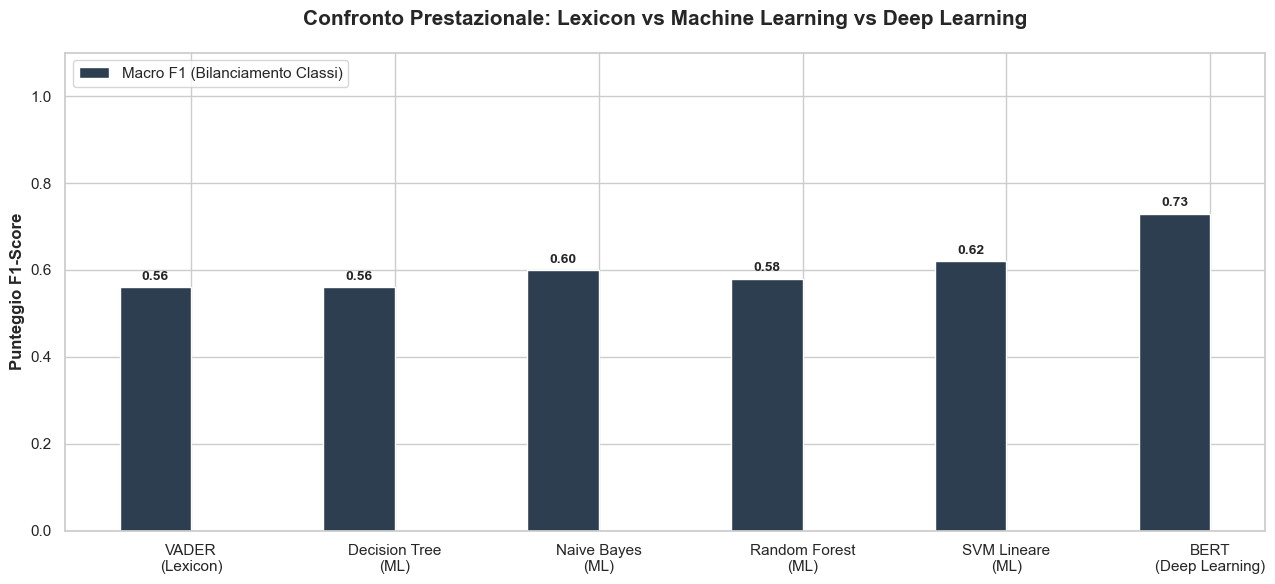

In [51]:
# 1. Definizione delle metriche

dati_confronto = {
    'Modello': [
        'VADER\n(Lexicon)', 
        'Decision Tree\n(ML)',
        'Naive Bayes\n(ML)', 
        'Random Forest\n(ML)', 
        'SVM Lineare\n(ML)', 
        'BERT\n(Deep Learning)'
    ],
    'Macro F1': [0.56, 0.56, 0.60, 0.58, 0.62, 0.73]
    
}

df_confronto = pd.DataFrame(dati_confronto)

# 2. Configurazione dello stile grafico
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(df_confronto['Modello']))
width = 0.35  # Larghezza delle barre

# 3. Creazione delle barre raggruppate
rects1 = ax.bar(x - width/2, df_confronto['Macro F1'], width, label='Macro F1 (Bilanciamento Classi)', color='#2c3e50')


# 4. Personalizzazione degli assi e della legenda
ax.set_ylabel('Punteggio F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Confronto Prestazionale: Lexicon vs Machine Learning vs Deep Learning', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_confronto['Modello'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left', fontsize=11)

# 5. Funzione per l'annotazione dei valori sulle barre
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)


plt.tight_layout()
plt.show()

**Il Limite delle Regole fisse e degli Alberi Decisionali**
 L'algoritmo Lexicon-Based (VADER) e il modello Decision Tree si posizionano al gradino più basso delle performance predittive, registrando entrambi un punteggio di 0.56. L'incapacità di VADER di adattarsi al dominio specifico e la tendenza dell'albero decisionale all'eccessiva frammentazione confermano l'inadeguatezza degli approcci di base per testi così complessi.

**La Fase Transitoria del Machine Learning**
 L'utilizzo di modelli statistici e vettoriali classici garantisce un modesto ma costante incremento delle prestazioni. Il Naive Bayes (0.60) supera leggermente la Random Forest (0.58), ma è la Support Vector Machine (SVM Lineare) a consolidarsi come il miglior modello della famiglia Bag-of-Words (0.62), toccando il picco massimo consentito da un'architettura che analizza la frequenza dei termini ma non preserva l'ordine sintattico del testo.

**L'Apice Predittivo del Deep Learning**
 Il modello LLM (BERT) ha compiuto un balzo in avanti di ben 11 punti decimali (0.73) rispetto alla SVM. Sfruttando la bidirezionalità contestuale e l'architettura a Transformer, la rete neurale dimostra una tenuta ineguagliata sulla complessità semantica del linguaggio umano, ponendosi come l'unico strumento idoneo per l'automazione affidabile del Customer Care.

## Conclusioni
L'analisi ha dimostrato come il passaggio da un'infrastruttura di classificazione vettoriale tradizionale (VADER) a un'architettura di Deep Learning (BERT) non rappresenti un mero esercizio accademico, ma una reale necessità operativa per decifrare la complessità del linguaggio umano all'interno del mercato dell'e-commerce di lusso.

Superando i limiti dei modelli Bag-of-Words, la rete neurale implementata si è dimostrata capace di isolare con elevata precisione le frustrazioni transazionali latenti, resistendo alle ambiguità sintattiche e al sarcasmo. Parallelamente, l'applicazione del Topic Modeling stocastico (LDA) ha permesso di destrutturare il malcontento, trasformando una massa informe di recensioni in una mappa diagnostica chiara e quantificabile.



**Autori**
*Elena Cascone*
*Alessandra Cosentino*